# Comprehensive Multi-Temperature Degradation Analysis — Experimental vs PyBaMM
### LG INR21700-M50T · Kirkaldy Experiment 5 · Cells A (10 °C), D (25 °C), F (40 °C)

This notebook produces **publication-quality** comparison figures between the measured
(experimental) ageing data and the PyBaMM DFN simulation, across **three temperatures**
simultaneously — the standard multi-temperature validation a journal paper would present.

For every degradation quantity we show **experimental vs simulated, for all three cells, on the
same axes**, so the temperature dependence and the model's fidelity to it are visible at a glance.

**Cells analysed**
| Cell | Chamber T | Coverage |
|------|-----------|----------|
| A | 10 °C | full life (RPT0–15, ~1170 cyc) |
| D | 25 °C | full life (RPT0–15, ~1170 cyc) |
| F | 40 °C | partial (RPT0–10, ~780 cyc — porosity-collapse limit at 40 °C) |

Each figure is preceded by a markdown cell explaining **what the quantity is**, **why it matters
for degradation diagnosis**, and **how to read the comparison**. Sections:

1. Setup & multi-cell data loading
2. **SoH fade — all temperatures** (the headline temperature-dependence figure)
3. **Capacity fade — all temperatures**
4. **Degradation Mode Analysis (DMA)** — LLI / LAM_NE / LAM_PE per temperature
5. **Electrode capacity** — PE / NE / Gr / Si per temperature
6. **Stoichiometry windows**
7. **Voltage discharge curves** — fresh vs aged, per temperature
8. **Incremental Capacity Analysis (ICA)** — dQ/dV fingerprints
9. **Differential Voltage Analysis (DVA)** — dV/dQ electrode balance
10. **Voltage at fixed depth-of-discharge** — polarization growth
11. **Coulombic efficiency & resistance**
12. **Temperature behaviour** (with measurement-definition caveat)
13. **Error analysis** — per-RPT capacity error & a master error table across all cells
14. **Arrhenius view** — fade rate vs temperature (the multi-T payoff plot)
15. **Summary dashboard**
16. **Feasibility verdict**

> All figures save to `./figures/` at 300 DPI. Set the two root paths in the **Setup** cell.

## 1 · Setup & Multi-Cell Data Loading

We load the **Processed Data** summary for each of the three cells (experimental + simulated), plus
their per-RPT **0.1C discharge curves** for the curve-level analyses. The loader is robust to the
two different naming schemes (exp `Expt 5 - cell A - RPT3 - 0.1C discharge data.csv` vs sim
`cell_A_RPT03_discharge.csv`) and to the `.xls`-that-is-really-CSV simulated files.

Cell F is expected to have fewer RPTs (porosity-collapse limit at 40 °C); the notebook compares
only the RPTs that exist on both sides for each cell, and labels the partial coverage.

In [1]:
import os, re, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
warnings.filterwarnings("ignore")

# ── ROOTS ── point these at your two trees ───────────────────────────────────
EXP_ROOT = r"D:\Mtech\Battery (MTP)\Stage 2\Data\IMP_1\Expt 5 - Standard Cycle Aging (Control)\exp_output_1"
SIM_ROOT = r"D:\Mtech\Battery (MTP)\Stage 2\Output Exp Data\kirkaldy pybamm\sim_output_7"

# cell -> (chamber temperature °C, colour)
CELLS = {"A": (10, "#2166AC"), "D": (25, "#1B7837"), "F": (40, "#B2182B")}
FIGDIR = "figures"; os.makedirs(FIGDIR, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 11, "axes.grid": True, "grid.alpha": 0.25,
    "legend.frameon": True, "legend.framealpha": 0.9, "legend.fontsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "lines.markersize": 5,
})
print("Setup complete. Cells:", {k:f"{v[0]}°C" for k,v in CELLS.items()})
print("Figures →", os.path.abspath(FIGDIR))

Setup complete. Cells: {'A': '10°C', 'D': '25°C', 'F': '40°C'}
Figures → C:\Users\yashb\ML\figures


In [2]:
# ── robust loaders ───────────────────────────────────────────────────────────
def find_files(root):
    out=[]
    for dp,_,fs in os.walk(root):
        for f in fs:
            if f.lower().endswith((".csv",".xls")): out.append(os.path.join(dp,f))
    return out

def load_any(p):
    if p.lower().endswith((".xls",".xlsx")):
        try:
            df=pd.read_excel(p)
            if df.shape[1]>1: return df
        except Exception: pass
    for sep in (",","\t",";"):
        try:
            df=pd.read_csv(p,sep=sep)
            if df.shape[1]>1: return df
        except Exception: continue
    return pd.read_csv(p)

def cell_of(p):
    m=re.search(r"cell[ _]*([a-h])",p.lower()); return m.group(1).upper() if m else None
def rpt_num(p):
    m=re.search(r"rpt[ _]*0*([0-9]+)",p.lower()); return int(m.group(1)) if m else None
def is_processed(p): return "processed" in p.lower()

EXP_FILES=find_files(EXP_ROOT); SIM_FILES=find_files(SIM_ROOT)
print(f"exp files {len(EXP_FILES)} | sim files {len(SIM_FILES)}")

def get_processed(files, cell):
    for p in files:
        if is_processed(p) and cell_of(p)==cell:
            df=load_any(p); df.columns=[c.strip() for c in df.columns]
            return df.sort_values("Ageing Cycles").reset_index(drop=True)
    return None

# Load aligned processed data for each cell
DATA={}   # cell -> dict(exp_df, sim_df, cyc)
for cell in CELLS:
    e=get_processed(EXP_FILES,cell); s=get_processed(SIM_FILES,cell)
    if e is None or s is None:
        print(f"  \u26a0 cell {cell}: exp={'ok' if e is not None else 'MISSING'} sim={'ok' if s is not None else 'MISSING'}"); continue
    common=sorted(set(e["Ageing Cycles"]) & set(s["Ageing Cycles"]))
    ec=e[e["Ageing Cycles"].isin(common)].reset_index(drop=True)
    sc=s[s["Ageing Cycles"].isin(common)].reset_index(drop=True)
    DATA[cell]=dict(exp=ec, sim=sc, cyc=ec["Ageing Cycles"].values,
                    exp_full=e, sim_full=s)   # full (un-intersected) series for the extrapolation plots
    print(f"  cell {cell} ({CELLS[cell][0]}\u00b0C): {len(common)} common RPTs \u2192 {int(common[0])}\u2013{int(common[-1])} cyc")


exp files 155 | sim files 57
  cell A (10°C): 16 common RPTs → 0–1170 cyc
  cell D (25°C): 16 common RPTs → 0–1170 cyc
  cell F (40°C): 16 common RPTs → 0–1170 cyc


In [3]:
# ── helpers ──────────────────────────────────────────────────────────────────
def col(df,name):
    for c in df.columns:
        if c.strip().lower()==name.lower(): return pd.to_numeric(df[c],errors="coerce").values
    return np.full(len(df),np.nan)

def err_stats(e,s):
    e=np.asarray(e,float); s=np.asarray(s,float)
    m=np.isfinite(e)&np.isfinite(s); e,s=e[m],s[m]
    if len(e)==0: return {}
    d=s-e
    return {"bias":d.mean(),"mae":np.abs(d).mean(),"rmse":np.sqrt((d**2).mean()),
            "mape":np.mean(np.abs(d)/np.where(np.abs(e)>1e-9,np.abs(e),np.nan))*100,
            "max":np.abs(d).max(),"n":len(e)}

def extend_sim_linear(cyc_sim, y_sim, cyc_target, n_fit=4):
    cyc_sim=np.asarray(cyc_sim,float); y_sim=np.asarray(y_sim,float)
    m=np.isfinite(cyc_sim)&np.isfinite(y_sim)
    cyc_sim,y_sim=cyc_sim[m],y_sim[m]
    if len(cyc_sim)<2 or cyc_target<=cyc_sim[-1]+1e-9:
        return None,None
    k=min(n_fit,len(cyc_sim))
    slope=np.polyfit(cyc_sim[-k:],y_sim[-k:],1)[0]
    x=np.array([cyc_sim[-1],float(cyc_target)])
    y=y_sim[-1]+slope*(x-cyc_sim[-1])
    return x,y


## 2 · State-of-Health Fade — All Temperatures

**What it is.** SoH = present C/10 capacity ÷ beginning-of-life C/10 capacity, the capacity-retention
curve, shown for all three temperatures together.

**Why it matters.** This is the headline multi-temperature validation. A correct model must reproduce
not just one fade curve but the **temperature ordering** — hotter cells fade faster — and the *rate*
of that acceleration. This single figure is the core evidence that the physics transfers across temperature.

**How to read it.** Solid = experimental, dashed = simulated, colour = temperature. For each colour the
two lines should overlie. The vertical spread between colours is the temperature effect; the model is
validated if it reproduces both the individual curves and their separation.

> **Cell F (40°C) note.** The PyBaMM run stops at the porosity-collapse solver limit (~702 cyc). For this figure only, the **simulated** curve is continued to the experimental end-of-coverage with a **linear extrapolation** (dotted line, legend *sim (extrapolated)*). The experimental data is the original, unchanged.

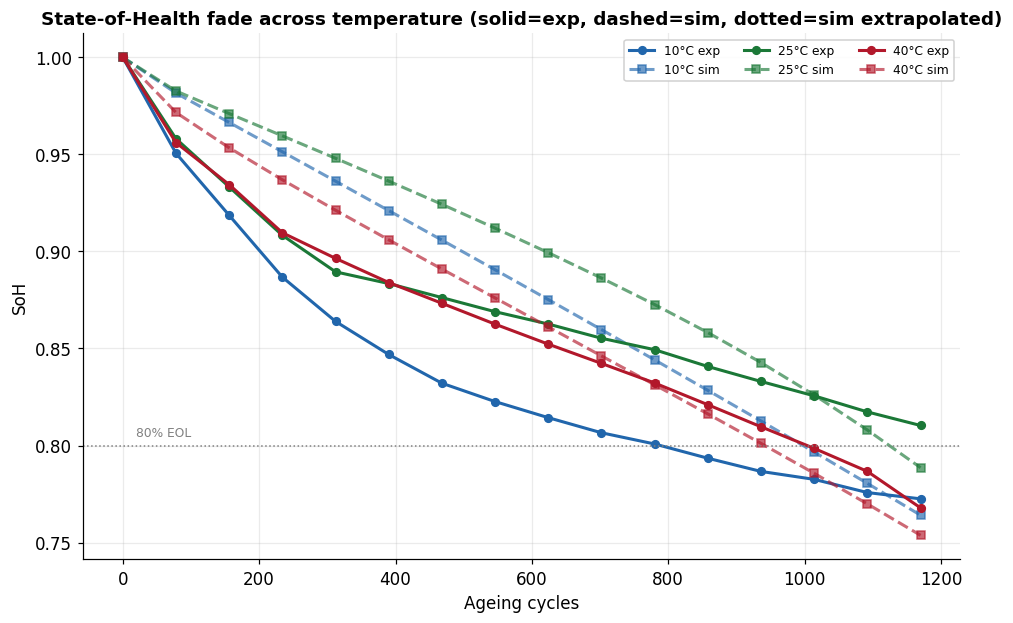

In [4]:
fig, ax = plt.subplots(figsize=(9,5.8))
for cell,(T,c) in CELLS.items():
    if cell not in DATA: continue
    d=DATA[cell]; ef=d["exp_full"]; sf=d["sim_full"]
    cyc_e=col(ef,"Ageing Cycles"); soh_e=col(ef,"SoH")
    cyc_s=col(sf,"Ageing Cycles"); soh_s=col(sf,"SoH")
    ax.plot(cyc_e, soh_e, "o-",  c=c, label=f"{T}\u00b0C exp")                 # original experimental
    ax.plot(cyc_s, soh_s, "s--", c=c, alpha=0.65, label=f"{T}\u00b0C sim")     # real simulation
    xe,ye=extend_sim_linear(cyc_s, soh_s, np.nanmax(cyc_e))                    # straight-line extension
    if xe is not None:
        ax.plot(xe, ye, ":", c=c, lw=2, alpha=0.9, label=f"{T}\u00b0C sim (extrapolated)")
        ax.scatter([xe[0]],[ye[0]], s=30, facecolors="none", edgecolors=c, zorder=5)
ax.axhline(0.8, color="grey", ls=":", lw=1); ax.text(20,0.805,"80% EOL",fontsize=8,color="grey")
ax.set_xlabel("Ageing cycles"); ax.set_ylabel("SoH")
ax.set_title("State-of-Health fade across temperature (solid=exp, dashed=sim, dotted=sim extrapolated)")
ax.legend(ncol=3, fontsize=8); plt.tight_layout(); plt.savefig(f"{FIGDIR}/fig02_soh_allT.png"); plt.show()


## 3 · Capacity Fade — All Temperatures

The same comparison in absolute C/10 capacity (mAh). Useful because it shows the beginning-of-life
capacity spread (cell-to-cell manufacturing variation, captured by the per-cell capacity factor) as
well as the fade.

> **Cell F (40°C) note.** Same treatment as the SoH figure: the **simulated** capacity is continued past the ~702-cyc PyBaMM solver limit to the experimental end-of-coverage with a **linear extrapolation** (dotted line, *sim (extrapolated)*). Experimental capacity is the original, unchanged.

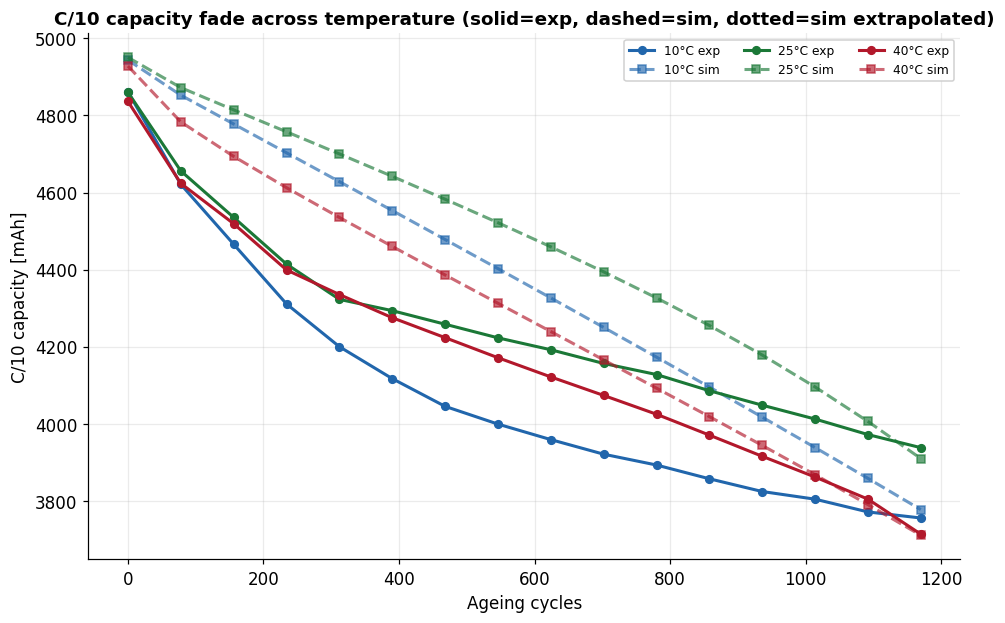

In [5]:

fig, ax = plt.subplots(figsize=(9,5.8))
for cell,(T,c) in CELLS.items():
    if cell not in DATA: continue
    d=DATA[cell]; ef=d["exp_full"]; sf=d["sim_full"]
    cyc_e=col(ef,"Ageing Cycles"); cap_e=col(ef,"C/10 Capacity [mA h]")
    cyc_s=col(sf,"Ageing Cycles"); cap_s=col(sf,"C/10 Capacity [mA h]")
    ax.plot(cyc_e, cap_e, "o-",  c=c, label=f"{T}\u00b0C exp")
    ax.plot(cyc_s, cap_s, "s--", c=c, alpha=0.65, label=f"{T}\u00b0C sim")
    xe,ye=extend_sim_linear(cyc_s, cap_s, np.nanmax(cyc_e))
    if xe is not None:
        ax.plot(xe, ye, ":", c=c, lw=2, alpha=0.9, label=f"{T}\u00b0C sim (extrapolated)")
        ax.scatter([xe[0]],[ye[0]], s=30, facecolors="none", edgecolors=c, zorder=5)
ax.set_xlabel("Ageing cycles"); ax.set_ylabel("C/10 capacity [mAh]")
ax.set_title("C/10 capacity fade across temperature (solid=exp, dashed=sim, dotted=sim extrapolated)")
ax.legend(ncol=3, fontsize=8); plt.tight_layout(); plt.savefig(f"{FIGDIR}/fig03_capacity_allT.png"); plt.show()


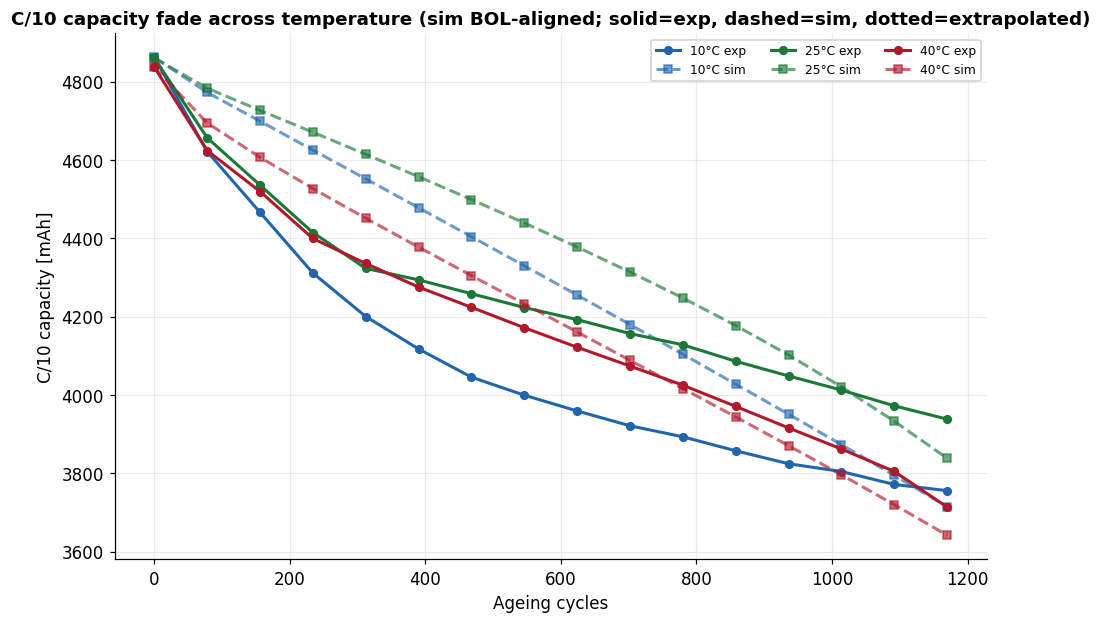

In [6]:
fig, ax = plt.subplots(figsize=(9,5.8))
for cell,(T,c) in CELLS.items():
    if cell not in DATA: continue
    d=DATA[cell]; ef=d["exp_full"]; sf=d["sim_full"]
    cyc_e=col(ef,"Ageing Cycles"); cap_e=col(ef,"C/10 Capacity [mA h]")
    cyc_s=col(sf,"Ageing Cycles"); cap_s=col(sf,"C/10 Capacity [mA h]")

    exp_bol = cap_e[0]
    sim_bol = cap_s[0]
    scale   = exp_bol / sim_bol            # multiplicative -> preserves fade shape
    cap_s_shifted = cap_s * scale

    ax.plot(cyc_e, cap_e, "o-",  c=c, label=f"{T}\u00b0C exp")
    ax.plot(cyc_s, cap_s_shifted, "s--", c=c, alpha=0.65, label=f"{T}\u00b0C sim")
    xe,ye=extend_sim_linear(cyc_s, cap_s_shifted, np.nanmax(cyc_e))   
    if xe is not None:
        ax.plot(xe, ye, ":", c=c, lw=2, alpha=0.9, label=f"{T}\u00b0C sim (extrapolated)")
        ax.scatter([xe[0]],[ye[0]], s=30, facecolors="none", edgecolors=c, zorder=5)
ax.set_xlabel("Ageing cycles"); ax.set_ylabel("C/10 capacity [mAh]")
ax.set_title("C/10 capacity fade across temperature (sim BOL-aligned; solid=exp, dashed=sim, dotted=extrapolated)")
ax.legend(ncol=3, fontsize=8); plt.tight_layout(); plt.savefig(f"{FIGDIR}/fig03_capacity_allT.png"); plt.show()

## 4 · Degradation Mode Analysis (DMA) — per Temperature

**What it is.** Capacity loss decomposed into **LLI** (lost cyclable lithium — SEI & plating),
**LAM_NE** (anode active-material loss — Gr/Si cracking) and **LAM_PE** (cathode active-material loss).

**Why it matters.** The *mechanism balance* is the heart of a physics model, and it is
**temperature-dependent**: at low T, plating-driven LLI grows; at high T, SEI-driven LLI and LAM
accelerate. Matching the partitioning at each temperature — not just the net capacity — is what makes
the simulated labels trustworthy for the PINN.

**How to read it.** One panel per temperature; within each, the three modes are shown exp (solid) vs
sim (dashed). Modes that track confirm the model degrades by the right mechanism at that temperature.

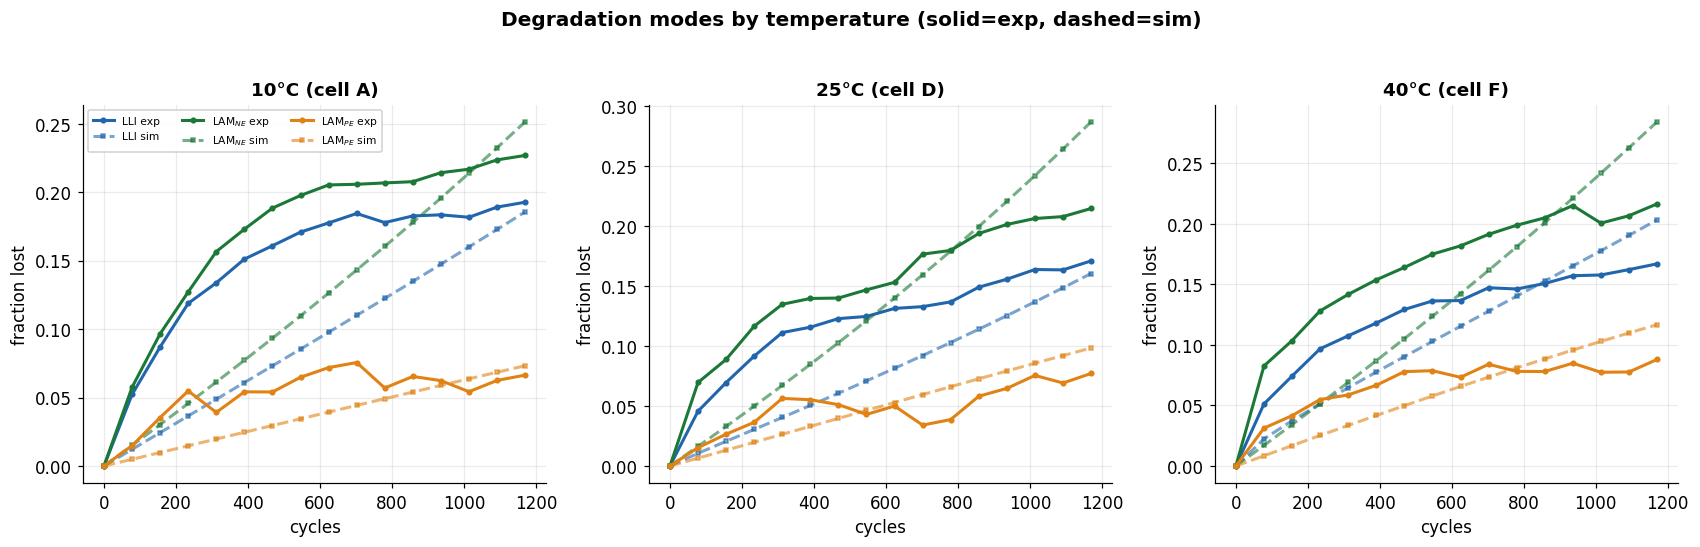

In [7]:
mode_cols=[("LLI","LLI","#2166AC"),("LAM NE_tot","LAM$_{NE}$","#1B7837"),("LAM PE","LAM$_{PE}$","#E08214")]
present=[c for c in CELLS if c in DATA]
fig, ax = plt.subplots(1, len(present), figsize=(5.2*len(present),4.8), squeeze=False)
for j,cell in enumerate(present):
    d=DATA[cell]; cyc=d["cyc"]; a=ax[0,j]
    for cn,lbl,cc in mode_cols:
        a.plot(cyc, col(d["exp"],cn), "o-",  c=cc, ms=3, label=f"{lbl} exp")
        a.plot(cyc, col(d["sim"],cn), "s--", c=cc, ms=3, alpha=0.6, label=f"{lbl} sim")
    a.set_title(f"{CELLS[cell][0]}°C (cell {cell})"); a.set_xlabel("cycles"); a.set_ylabel("fraction lost")
    if j==0: a.legend(fontsize=7,ncol=3)
plt.suptitle("Degradation modes by temperature (solid=exp, dashed=sim)", fontweight="bold", y=1.03)
plt.tight_layout(); plt.savefig(f"{FIGDIR}/fig04_dma_perT.png"); plt.show()

## 5 · Electrode-Level Capacity — per Temperature

PE, NE, and the graphite/silicon split of the anode. Silicon degrades faster than graphite (large
volume change → cracking) and that gap *widens with temperature*. Tracking Gr and Si separately at
each temperature shows whether the model captures the silicon-driven, temperature-accelerated anode fade.

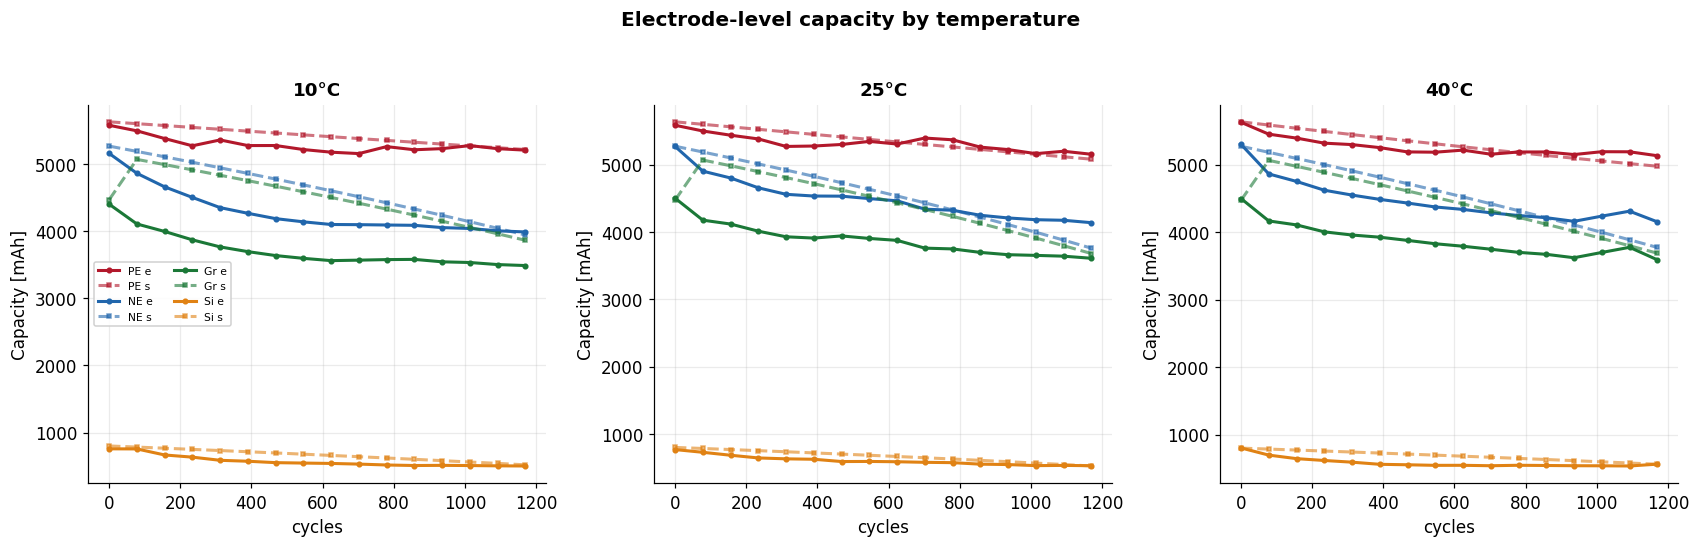

In [8]:
comp=[("PE Capacity [mA h]","PE","#B2182B"),("NE Capacity [mA h]","NE","#2166AC"),
      ("NE_Gr Capacity [mA h]","Gr","#1B7837"),("NE_Si Capacity [mA h]","Si","#E08214")]
fig, ax = plt.subplots(1,len(present),figsize=(5.2*len(present),4.8),squeeze=False)
for j,cell in enumerate(present):
    d=DATA[cell]; cyc=d["cyc"]; a=ax[0,j]
    for cn,lbl,cc in comp:
        a.plot(cyc,col(d["exp"],cn),"o-",c=cc,ms=3,label=f"{lbl} e")
        a.plot(cyc,col(d["sim"],cn),"s--",c=cc,ms=3,alpha=0.6,label=f"{lbl} s")
    a.set_title(f"{CELLS[cell][0]}°C"); a.set_xlabel("cycles"); a.set_ylabel("Capacity [mAh]")
    if j==0: a.legend(fontsize=7,ncol=2)
plt.suptitle("Electrode-level capacity by temperature", fontweight="bold", y=1.03)
plt.tight_layout(); plt.savefig(f"{FIGDIR}/fig05_electrode_perT.png"); plt.show()

## 6 · Electrode Stoichiometry Windows

`PE_lo/PE_hi` and `NE_lo/NE_hi` are the lithiation limits each electrode swings between. LLI slides
the windows relative to each other; LAM compresses them. Matching their slippage confirms the model
degrades the electrode *balance* correctly, not just the net capacity. Shown for the 10 °C cell as the
representative full-life case (the same code works for any cell by changing `ref`).

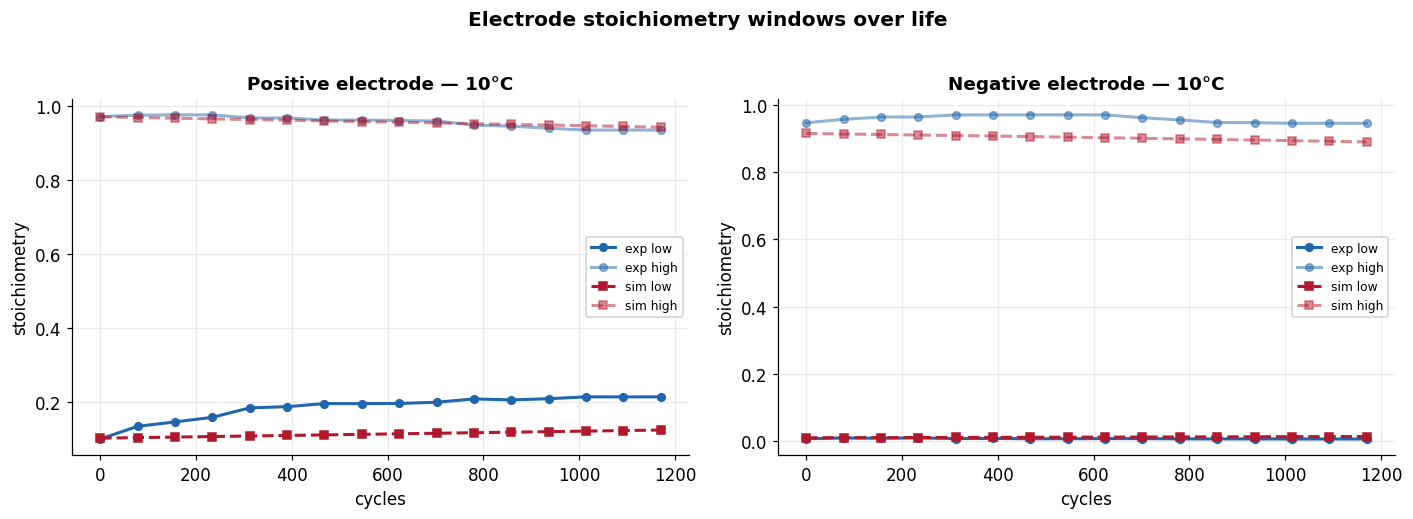

In [9]:
ref = "A" if "A" in DATA else present[0]
d=DATA[ref]; cyc=d["cyc"]
fig, ax = plt.subplots(1,2,figsize=(13,4.6))
for lo,hi,a,name in [("PE_lo","PE_hi",ax[0],"Positive electrode"),("NE_lo","NE_hi",ax[1],"Negative electrode")]:
    a.plot(cyc,col(d["exp"],lo),"o-",c="#2166AC",label="exp low")
    a.plot(cyc,col(d["exp"],hi),"o-",c="#2166AC",alpha=0.5,label="exp high")
    a.plot(cyc,col(d["sim"],lo),"s--",c="#B2182B",label="sim low")
    a.plot(cyc,col(d["sim"],hi),"s--",c="#B2182B",alpha=0.5,label="sim high")
    a.set_title(f"{name} — {CELLS[ref][0]}°C"); a.set_xlabel("cycles"); a.set_ylabel("stoichiometry"); a.legend(fontsize=8)
plt.suptitle("Electrode stoichiometry windows over life", fontweight="bold", y=1.02)
plt.tight_layout(); plt.savefig(f"{FIGDIR}/fig06_stoich.png"); plt.show()

## 7 · Voltage Discharge Curves (0.1C) — fresh vs aged, per Temperature

**What it is.** The terminal-voltage-vs-capacity curve from each RPT's slow C/10 discharge.

**Why it matters.** This is the raw measurement everything else derives from. If the V–Q curves match,
the model's thermodynamics and resistance are right. We overlay fresh (RPT0) and the most-aged available
RPT for each temperature, so both the fresh-cell fidelity and the aged drift are visible.

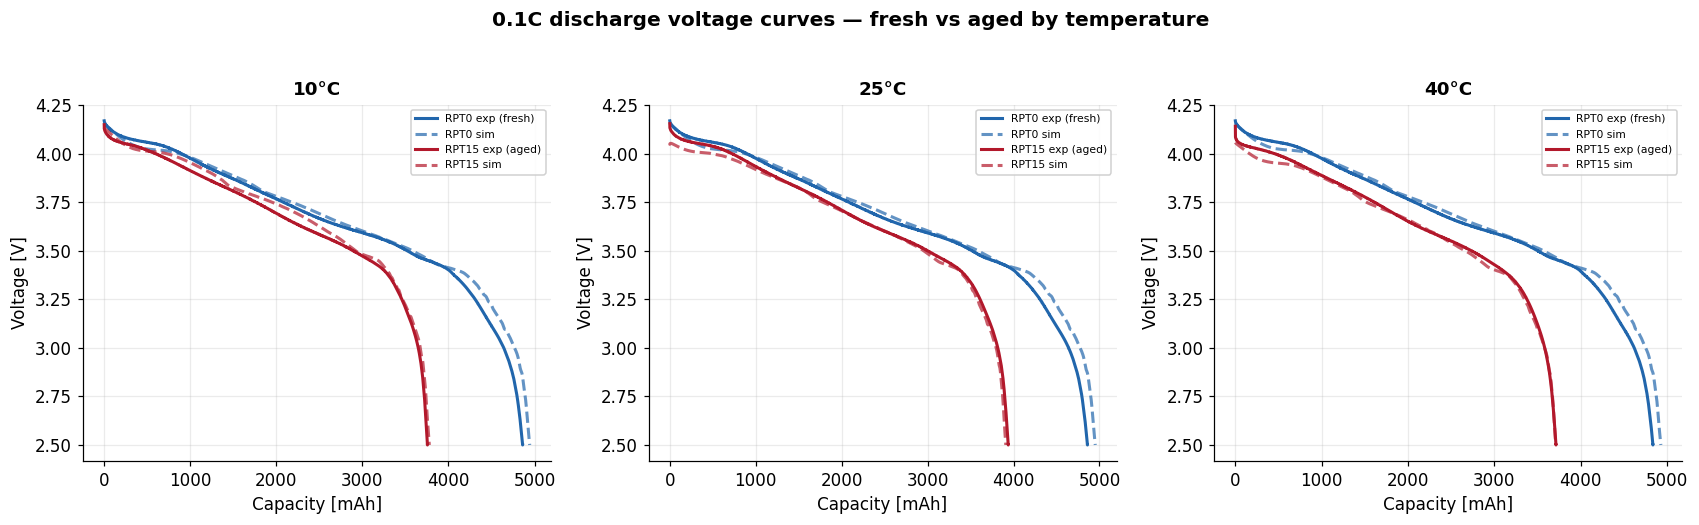

In [10]:
def load_curves(files, cell):
    out={}
    for p in files:
        if cell_of(p)!=cell: continue
        b=p.lower()
        if "gitt" in b or "pulse" in b: continue
        is_exp = ("discharge" in b) and ("0.1c" in b or "0_1c" in b)
        is_sim = bool(re.search(r"rpt[ _]*\d+_discharge", b))
        if is_exp or is_sim:
            n=rpt_num(p)
            if n is not None and n not in out: out[n]=load_any(p)
    return out

def vq(df):
    cols={c.strip().lower():c for c in df.columns}
    vcol=next((cols[k] for k in cols if k in ("voltage (v)","v [v]","voltage","v")),None)
    qcol=next((cols[k] for k in cols if k in ("charge (ma.h)","q [mah]","charge (mah)","capacity")),None)
    if vcol is None or qcol is None: return None,None
    V=pd.to_numeric(df[vcol],errors="coerce").values
    Q=np.abs(pd.to_numeric(df[qcol],errors="coerce").values)
    m=np.isfinite(V)&np.isfinite(Q); return Q[m],V[m]

CURVES={}
for cell in present:
    CURVES[cell]=dict(exp=load_curves(EXP_FILES,cell), sim=load_curves(SIM_FILES,cell))

fig, ax = plt.subplots(1,len(present),figsize=(5.2*len(present),4.6),squeeze=False)
for j,cell in enumerate(present):
    a=ax[0,j]; ec=CURVES[cell]["exp"]; sc=CURVES[cell]["sim"]
    common=sorted(set(ec)&set(sc))
    if not common:
        a.text(0.5,0.5,"no overlapping curves",ha="center",transform=a.transAxes); continue
    for r,style in [(common[0],"fresh"),(common[-1],"aged")]:
        cc = "#2166AC" if style=="fresh" else "#B2182B"
        qe,ve=vq(ec[r]); qs,vs=vq(sc[r])
        if qe is not None: a.plot(qe,ve,"-",c=cc,label=f"RPT{r} exp ({style})")
        if qs is not None: a.plot(qs,vs,"--",c=cc,alpha=0.7,label=f"RPT{r} sim")
    a.set_title(f"{CELLS[cell][0]}°C"); a.set_xlabel("Capacity [mAh]"); a.set_ylabel("Voltage [V]"); a.legend(fontsize=7)
plt.suptitle("0.1C discharge voltage curves — fresh vs aged by temperature", fontweight="bold", y=1.03)
plt.tight_layout(); plt.savefig(f"{FIGDIR}/fig07_voltage_curves.png"); plt.show()

## 8 · Incremental Capacity Analysis (ICA): dQ/dV — All Three Temperatures

**What it is.** dQ/dV vs voltage — plateaus in the V–Q curve become peaks; each peak is an electrode
phase transition.

**Why it matters.** The standard non-destructive degradation fingerprint, and it is the *true*
apples-to-apples partitioning check because identical processing is applied to exp and sim:
- **Peak position** (voltage) shifts track **LLI** (electrodes slip relative to each other).
- **Peak height / area** shrinks track **LAM** (less active material → smaller peak).

**How to read it.** Top row = fresh (RPT0), bottom row = most-aged available RPT; one column per
temperature (10 / 25 / 40 °C). Aligned peaks = correct LLI; matched heights = correct LAM. Comparing
across the three columns shows whether the model captures how the degradation fingerprint changes with
temperature — the multi-temperature ICA validation a paper would present.

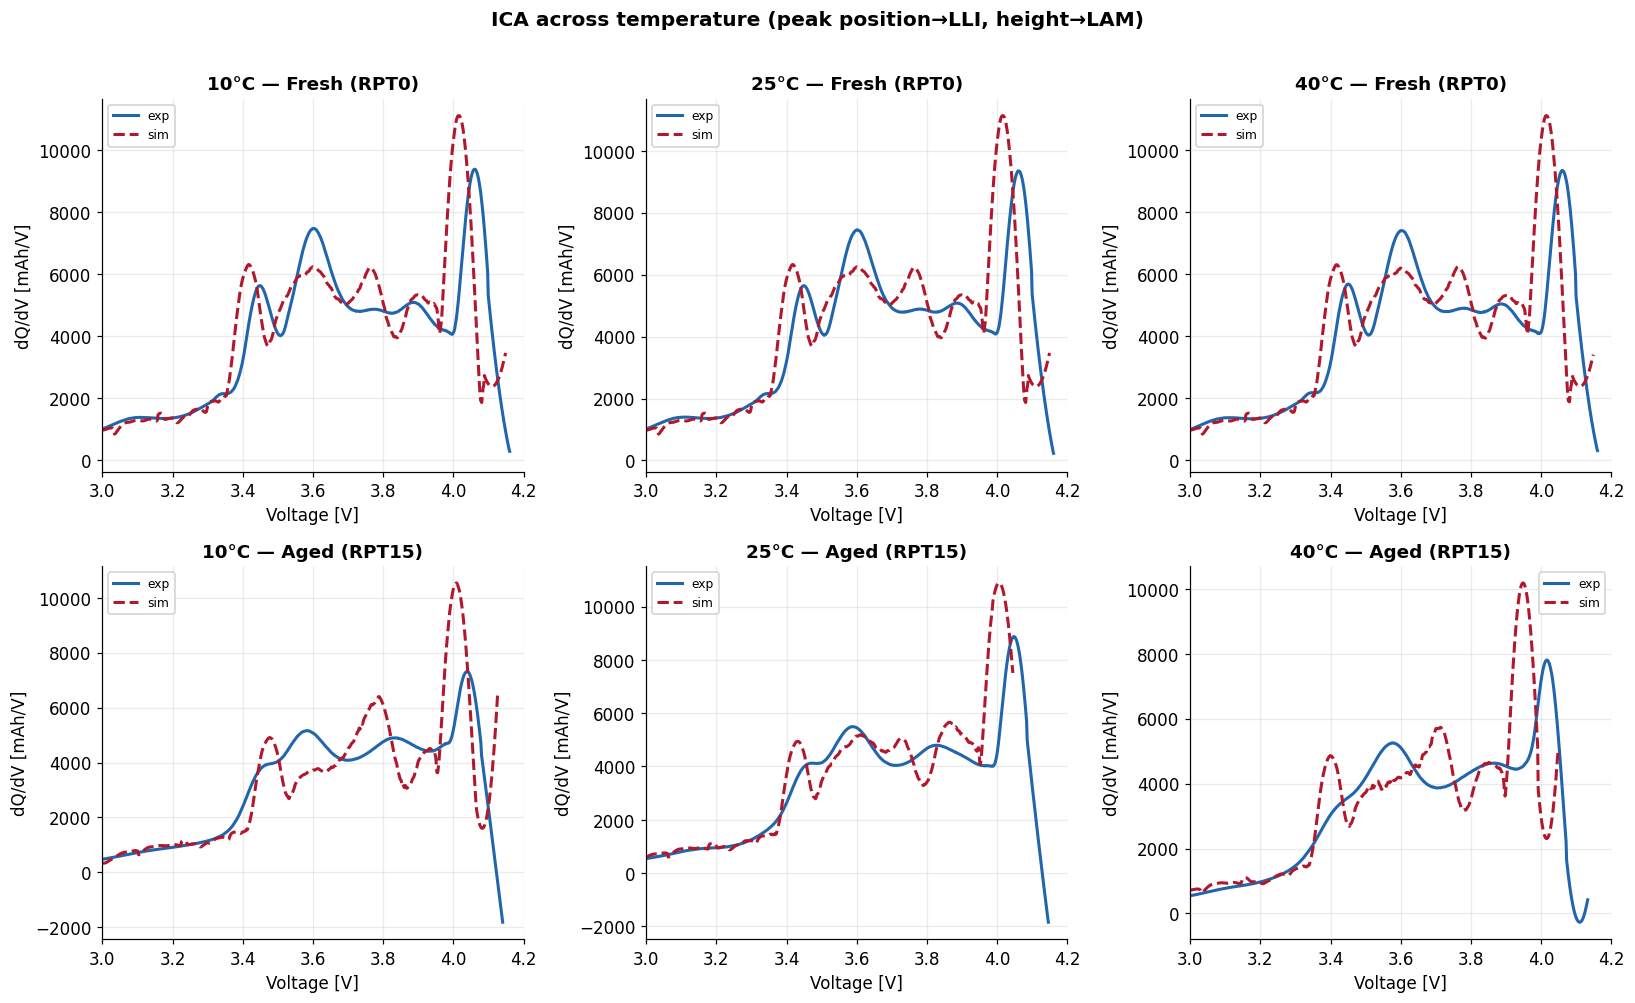

In [11]:
def compute_ica(Q,V,npts=2000,win=151,poly=3,invert_y=True):
    order=np.argsort(V); V,Q=V[order],Q[order]
    keep=np.concatenate([[True],np.diff(V)>1e-6]); V,Q=V[keep],Q[keep]
    if len(V)<win+2: return None,None
    vg=np.linspace(V.min()+0.01,V.max()-0.01,npts)
    qg=interp1d(V,Q,bounds_error=False,fill_value="extrapolate")(vg)
    w=min(win,(len(qg)//2)*2-1); qs=savgol_filter(qg,w,poly)
    dqdv = np.gradient(qs,vg)
    if invert_y:                 # flip peaks vertically (dQ/dV -> -dQ/dV)
        dqdv = -dqdv
    return vg, dqdv

# ---- display toggles ----
INVERT_Y = True     # True = peaks point downward (negate dQ/dV)
INVERT_X = False    # True = voltage axis high->low (discharge direction)

ncell=len(present)
fig, ax = plt.subplots(2, ncell, figsize=(5.0*ncell, 9), squeeze=False)
for j,cell in enumerate(present):
    T=CELLS[cell][0]
    ec=CURVES[cell]["exp"]; sc=CURVES[cell]["sim"]; common=sorted(set(ec)&set(sc))
    if not common:
        ax[0,j].text(0.5,0.5,"no overlapping curves",ha="center",transform=ax[0,j].transAxes); continue
    panels=[(common[0],0,"Fresh"),(common[-1],1,"Aged")] if len(common)>1 else [(common[0],0,"Fresh")]
    for r,row,ttl in panels:
        a=ax[row,j]
        qe,ve=vq(ec[r]); qs,vs=vq(sc[r])
        vge,ie=compute_ica(qe,ve,invert_y=INVERT_Y); vgs,isi=compute_ica(qs,vs,invert_y=INVERT_Y)
        if vge is not None: a.plot(vge,ie,"-",c="#2166AC",label="exp")
        if vgs is not None: a.plot(vgs,isi,"--",c="#B2182B",label="sim")
        if INVERT_X:
            a.set_xlim(4.2,3.0)          # high -> low (discharge direction)
        else:
            a.set_xlim(3.0,4.2)
        a.set_title(f"{T}°C — {ttl} (RPT{r})")
        a.set_xlabel("Voltage [V]"); a.set_ylabel("dQ/dV [mAh/V]"); a.legend(fontsize=8)
plt.suptitle("ICA across temperature (peak position→LLI, height→LAM)", fontweight="bold", y=1.01)
plt.tight_layout(); plt.savefig(f"{FIGDIR}/fig08_ica_allT.png"); plt.show()

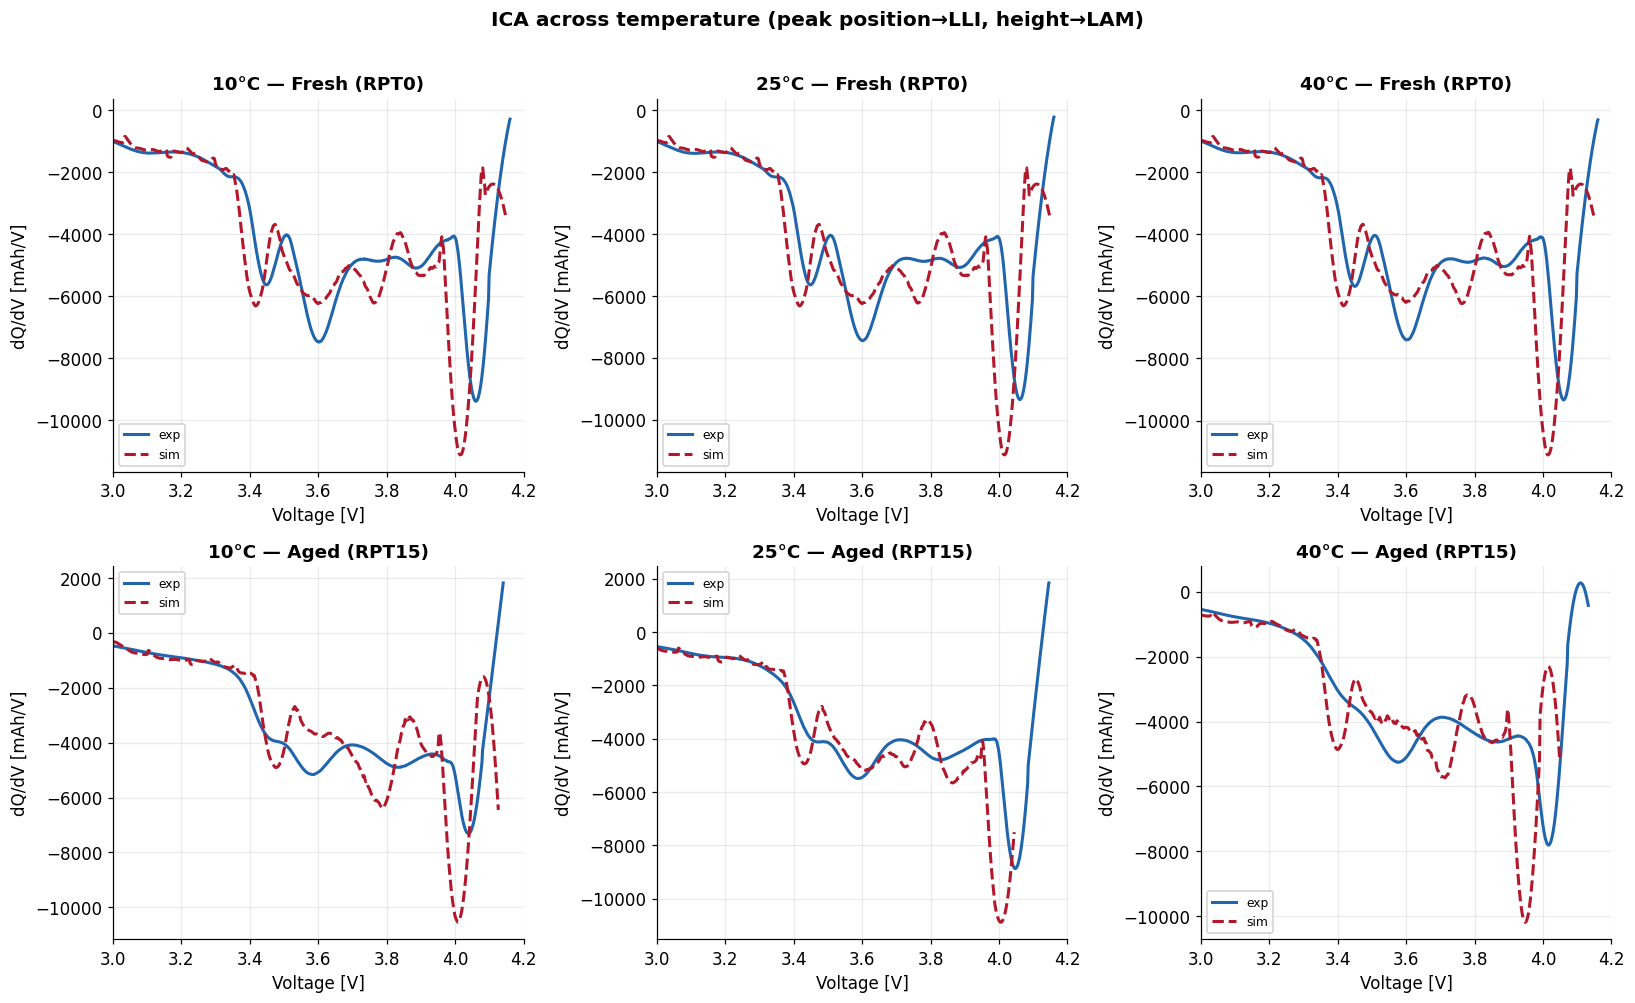

In [12]:
def compute_ica(Q,V,npts=2000,win=151,poly=3):
    order=np.argsort(V); V,Q=V[order],Q[order]
    keep=np.concatenate([[True],np.diff(V)>1e-6]); V,Q=V[keep],Q[keep]
    if len(V)<win+2: return None,None
    vg=np.linspace(V.min()+0.01,V.max()-0.01,npts)
    qg=interp1d(V,Q,bounds_error=False,fill_value="extrapolate")(vg)
    w=min(win,(len(qg)//2)*2-1); qs=savgol_filter(qg,w,poly)
    return vg, np.gradient(qs,vg)

ncell=len(present)
fig, ax = plt.subplots(2, ncell, figsize=(5.0*ncell, 9), squeeze=False)
for j,cell in enumerate(present):
    T=CELLS[cell][0]
    ec=CURVES[cell]["exp"]; sc=CURVES[cell]["sim"]; common=sorted(set(ec)&set(sc))
    if not common:
        ax[0,j].text(0.5,0.5,"no overlapping curves",ha="center",transform=ax[0,j].transAxes); continue
    panels=[(common[0],0,"Fresh"),(common[-1],1,"Aged")] if len(common)>1 else [(common[0],0,"Fresh")]
    for r,row,ttl in panels:
        a=ax[row,j]
        qe,ve=vq(ec[r]); qs,vs=vq(sc[r])
        vge,ie=compute_ica(qe,ve); vgs,isi=compute_ica(qs,vs)
        if vge is not None: a.plot(vge,ie,"-",c="#2166AC",label="exp")
        if vgs is not None: a.plot(vgs,isi,"--",c="#B2182B",label="sim")
        a.set_xlim(3.0,4.2); a.set_title(f"{T}°C — {ttl} (RPT{r})")
        a.set_xlabel("Voltage [V]"); a.set_ylabel("dQ/dV [mAh/V]"); a.legend(fontsize=8)
plt.suptitle("ICA across temperature (peak position→LLI, height→LAM)", fontweight="bold", y=1.01)
plt.tight_layout(); plt.savefig(f"{FIGDIR}/fig08_ica_allT.png"); plt.show()

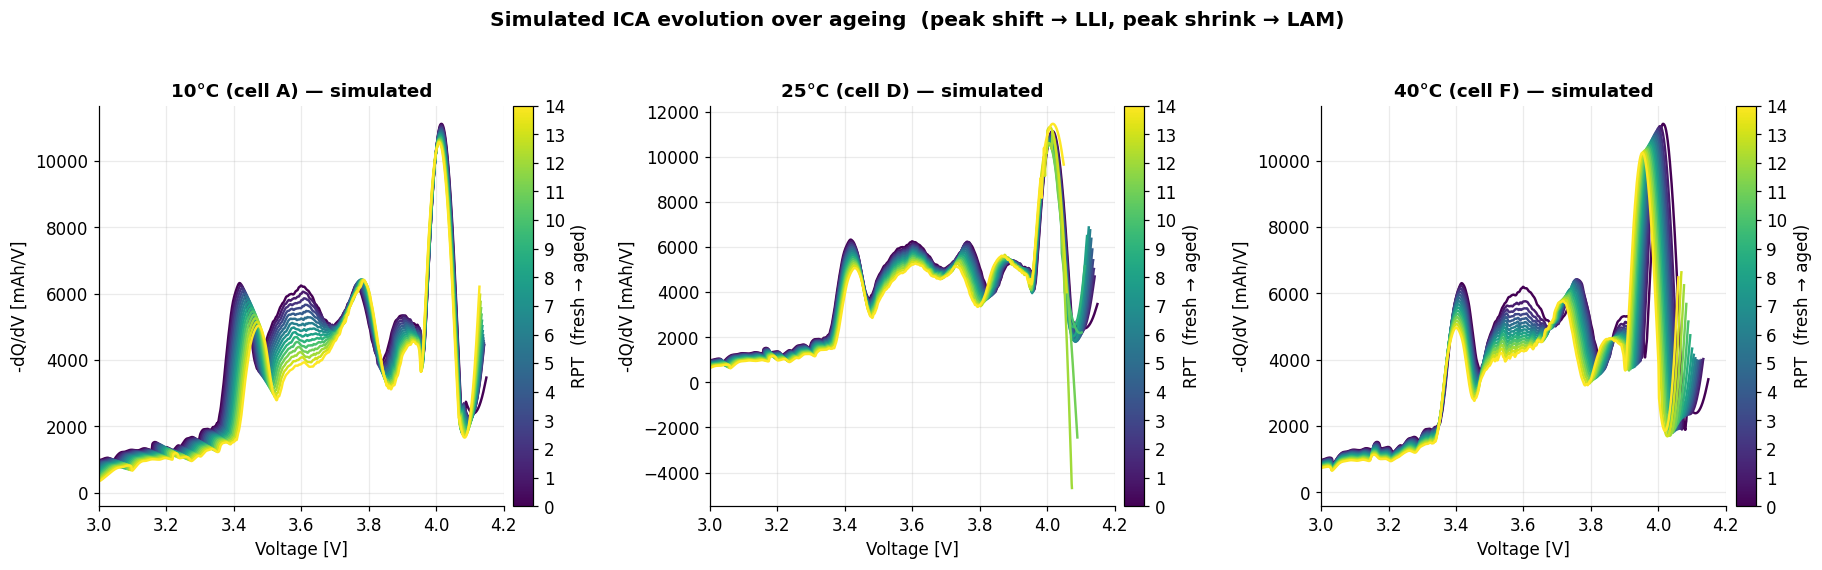

In [13]:
from matplotlib.colors import Normalize

CYC_PER_RPT = 78   # Kirkaldy protocol: ~78 ageing cycles per RPT interval

RPT_LIMIT = {"A": 15, "D": 15, "F": 15}

def _ica(Q, V, npts=2000, win=151, poly=3):
    # dQ/dV vs V with the same Savitzky-Golay smoothing the notebook uses for ICA
    order = np.argsort(V); V, Q = V[order], Q[order]
    keep = np.concatenate([[True], np.diff(V) > 1e-6]); V, Q = V[keep], Q[keep]
    if len(V) < win + 2: return None, None
    vg = np.linspace(V.min() + 0.01, V.max() - 0.01, npts)
    qg = interp1d(V, Q, bounds_error=False, fill_value="extrapolate")(vg)
    w = min(win, (len(qg) // 2) * 2 - 1)
    qs = savgol_filter(qg, w, poly)
    return vg, np.gradient(qs, vg)

# cells that actually have simulated discharge curves
panels = [c for c in present if CURVES.get(c, {}).get("sim")]
if not panels:
    print("No simulated discharge curves found in CURVES — run the curve-loading cell first.")
else:
    cmap = plt.get_cmap("viridis")
    fig, ax = plt.subplots(1, len(panels), figsize=(5.6 * len(panels), 5.0), squeeze=False)
    for j, cell in enumerate(panels):
        a = ax[0, j]
        sim = CURVES[cell]["sim"]
        rpts = sorted(sim)
        lim = RPT_LIMIT.get(cell)
        if lim is not None:
            rpts = rpts[:lim]          
        if not rpts:
            continue
        norm = Normalize(vmin=min(rpts), vmax=max(rpts))
        for r in rpts:
            q, v = vq(sim[r])
            if q is None: continue
            vg, dqdv = _ica(q, v)
            if vg is None: continue
            a.plot(vg, -dqdv, color=cmap(norm(r)), lw=1.6,
                   label=f"RPT{r} (~{r * CYC_PER_RPT} cyc)")
        a.set_xlim(3.0, 4.2)
        a.set_title(f"{CELLS[cell][0]}\u00b0C (cell {cell}) — simulated", fontweight="bold")
        a.set_xlabel("Voltage [V]"); a.set_ylabel("-dQ/dV [mAh/V]")
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
        cb = fig.colorbar(sm, ax=a, pad=0.02)
        cb.set_label("RPT  (fresh \u2192 aged)")
        cb.set_ticks(rpts)
    plt.suptitle("Simulated ICA evolution over ageing  (peak shift \u2192 LLI, peak shrink \u2192 LAM)",
                 fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig(f"{FIGDIR}/fig08b_ica_sim_allRPT.png", dpi=300)
    plt.show()

## 9 · Differential Voltage Analysis (DVA): dV/dQ — All Three Temperatures

**What it is.** dV/dQ vs capacity — the reciprocal derivative. Feature *positions along the capacity
axis* mark the electrode balance and graphite staging transitions.

**Why it matters.** DVA is especially sensitive to electrode-specific capacity. The spacing between
features quantifies how much usable capacity sits in each electrode — a direct check on the NE/PE
split, and on how that balance shifts with temperature.

**How to read it.** Same layout as ICA: top row fresh, bottom row aged, one column per temperature.
Feature positions on the capacity axis should align between exp (solid) and sim (dashed); drift
indicates the model has the electrode capacities or balance slightly off at that temperature.

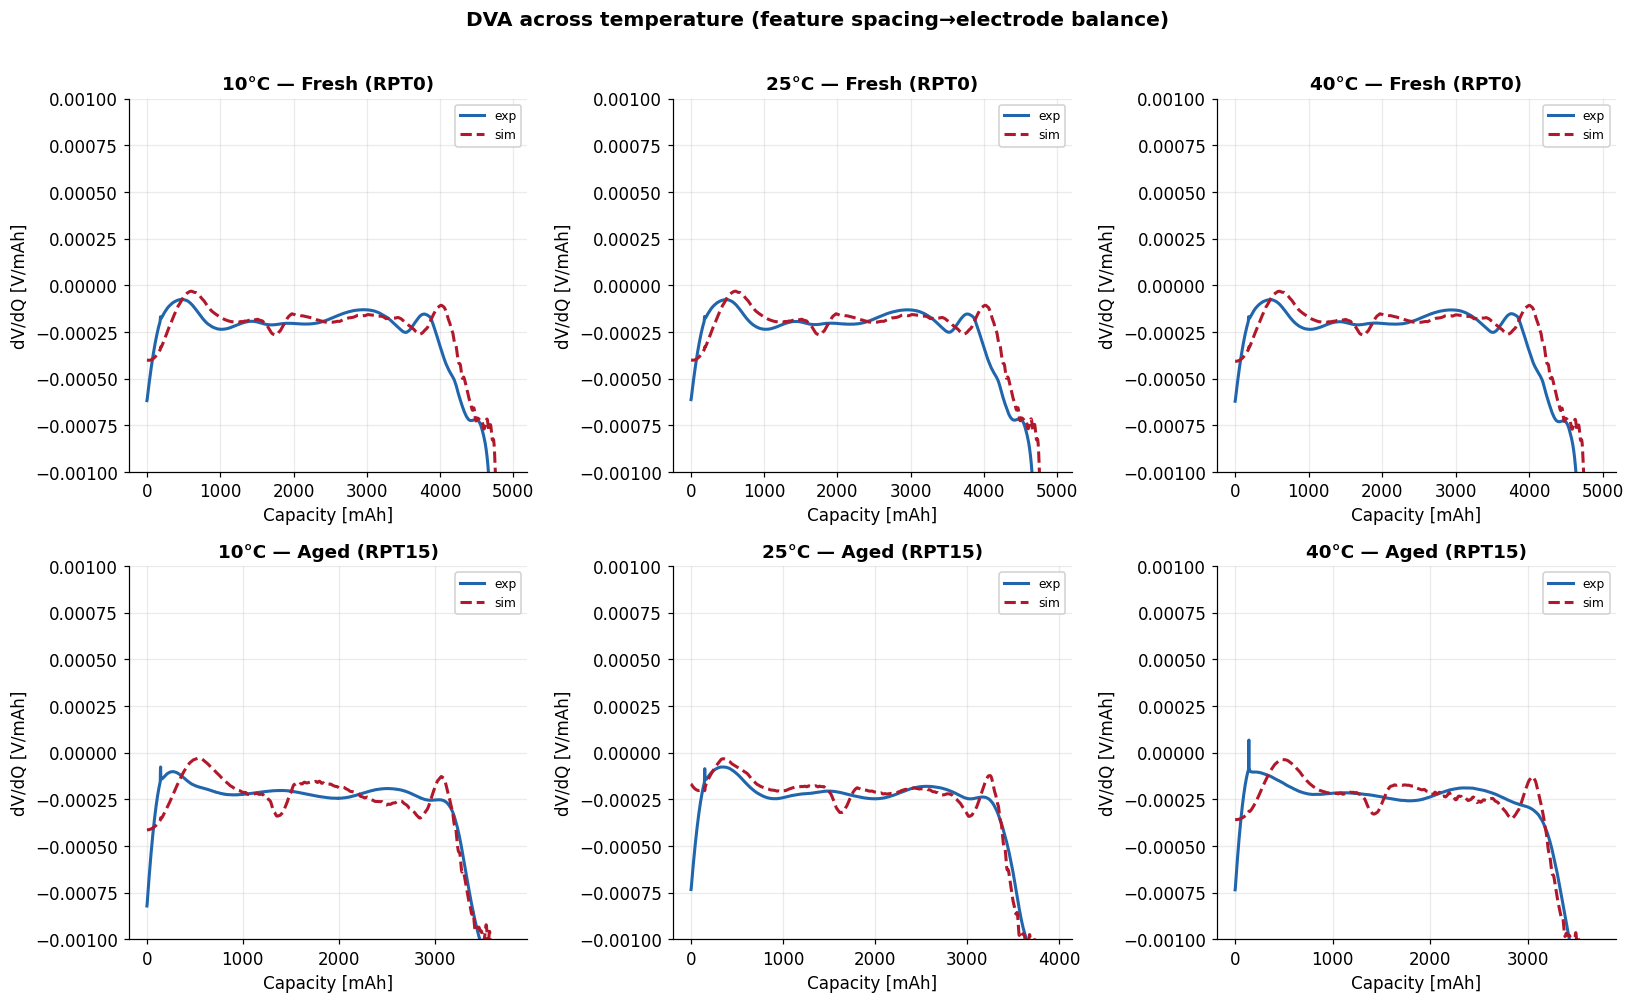

In [14]:
def compute_dva(Q,V,npts=2000,win=151,poly=3):
    order=np.argsort(Q); Q,V=Q[order],V[order]
    keep=np.concatenate([[True],np.diff(Q)>1e-6]); Q,V=Q[keep],V[keep]
    if len(Q)<win+2: return None,None
    qg=np.linspace(Q.min(),Q.max(),npts)
    vg=interp1d(Q,V,bounds_error=False,fill_value="extrapolate")(qg)
    w=min(win,(len(vg)//2)*2-1); vs=savgol_filter(vg,w,poly)
    return qg, np.gradient(vs,qg)

fig, ax = plt.subplots(2, ncell, figsize=(5.0*ncell, 9), squeeze=False)
for j,cell in enumerate(present):
    T=CELLS[cell][0]
    ec=CURVES[cell]["exp"]; sc=CURVES[cell]["sim"]; common=sorted(set(ec)&set(sc))
    if not common:
        ax[0,j].text(0.5,0.5,"no overlapping curves",ha="center",transform=ax[0,j].transAxes); continue
    panels=[(common[0],0,"Fresh"),(common[-1],1,"Aged")] if len(common)>1 else [(common[0],0,"Fresh")]
    for r,row,ttl in panels:
        a=ax[row,j]
        qe,ve=vq(ec[r]); qs,vs=vq(sc[r])
        qge,de=compute_dva(qe,ve); qgs,ds=compute_dva(qs,vs)
        if qge is not None: a.plot(qge,de,"-",c="#2166AC",label="exp")
        if qgs is not None: a.plot(qgs,ds,"--",c="#B2182B",label="sim")
        a.set_ylim(-1e-3,1e-3); a.set_title(f"{T}°C — {ttl} (RPT{r})")
        a.set_xlabel("Capacity [mAh]"); a.set_ylabel("dV/dQ [V/mAh]"); a.legend(fontsize=8)
plt.suptitle("DVA across temperature (feature spacing→electrode balance)", fontweight="bold", y=1.01)
plt.tight_layout(); plt.savefig(f"{FIGDIR}/fig09_dva_allT.png"); plt.show()

## 10 · Quantitative Error Analysis — All Cells

Per-RPT capacity error (%) for each temperature on one axis, plus a **master error table** (RMSE / MAPE /
bias / max) for every degradation quantity and every cell. The target for the PINN pipeline is
**< 3 % absolute capacity error on aged data**; the ±3 % band is marked.

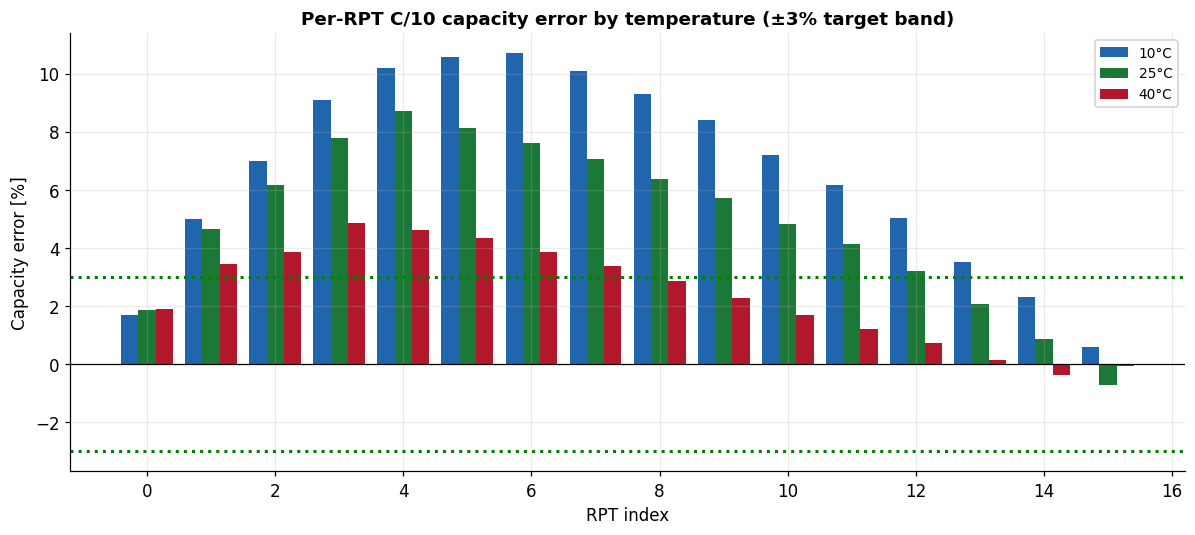

Cell T Quantity    RMSE MAPE %      bias max|err|
  10°C      SoH 0.04924    5.0  +0.04126  0.07415
  10°C Capacity   303.8    6.7      +273    436.1
  10°C      LLI  0.0623    nan  -0.05453  0.09024
  10°C   LAM_NE 0.06233    nan  -0.04816  0.09581
  10°C   LAM_PE 0.02172    nan  -0.01524  0.04007
  10°C   PE cap   160.3    2.6    +134.7    274.4
  10°C   NE cap   402.8    8.2    +344.2      595
  25°C      SoH 0.03432    3.3  +0.02523   0.0585
  25°C Capacity   241.2    5.0    +210.7    377.4
  25°C      LLI 0.04469    nan     -0.04  0.07085
  25°C   LAM_NE 0.04376    nan  -0.01267   0.0723
  25°C   LAM_PE 0.01764    nan +0.002505  0.02997
  25°C   PE cap   104.4    1.7    +34.08    216.6
  25°C   NE cap   231.7    4.3    +69.74    378.5
  40°C      SoH 0.01536    1.5 +0.005912   0.0273
  40°C Capacity   127.7    2.5    +104.4    213.4
  40°C      LLI  0.0294    nan  -0.01369  0.04546
  40°C   LAM_NE 0.05189    nan  -0.02382  0.07663
  40°C   LAM_PE 0.02154    nan -0.005256  0.03225


In [16]:
fig, ax = plt.subplots(figsize=(11,5))
width=0.27; offs={"A":-width,"D":0,"F":width}
for cell,(T,c) in CELLS.items():
    if cell not in DATA: continue
    d=DATA[cell]; cyc=d["cyc"]
    ce=(col(d["sim"],"C/10 Capacity [mA h]")-col(d["exp"],"C/10 Capacity [mA h]"))/col(d["exp"],"C/10 Capacity [mA h]")*100
    x=np.arange(len(cyc))+offs.get(cell,0)
    ax.bar(x,ce,width,color=c,label=f"{T}°C")
ax.axhline(3,color="green",ls=":"); ax.axhline(-3,color="green",ls=":"); ax.axhline(0,color="k",lw=0.8)
ax.set_xlabel("RPT index"); ax.set_ylabel("Capacity error [%]")
ax.set_title("Per-RPT C/10 capacity error by temperature (±3% target band)")
ax.legend(); plt.tight_layout(); plt.savefig(f"{FIGDIR}/fig13_caperror_allT.png"); plt.show()

# master error table
rows=[]
qtys=[("SoH","SoH"),("C/10 Capacity [mA h]","Capacity"),("LLI","LLI"),
      ("LAM NE_tot","LAM_NE"),("LAM PE","LAM_PE"),
      ("PE Capacity [mA h]","PE cap"),("NE Capacity [mA h]","NE cap")]
for cell in present:
    d=DATA[cell]
    for cn,lbl in qtys:
        st=err_stats(col(d["exp"],cn),col(d["sim"],cn))
        if st: rows.append([f"{CELLS[cell][0]}°C",lbl,f"{st['rmse']:.4g}",f"{st['mape']:.1f}",f"{st['bias']:+.4g}",f"{st['max']:.4g}"])
err_df=pd.DataFrame(rows,columns=["Cell T","Quantity","RMSE","MAPE %","bias","max|err|"])
print(err_df.to_string(index=False)); err_df.to_csv(f"{FIGDIR}/master_error_table.csv",index=False)

In [ ]:
Ts=[]; fade_e=[]; fade_s=[]
for cell,(T,c) in CELLS.items():
    if cell not in DATA: continue
    d=DATA[cell]
    Ts.append(T); fade_e.append((1-col(d["exp"],"SoH")[-1])*100); fade_s.append((1-col(d["sim"],"SoH")[-1])*100)
order=np.argsort(Ts); Ts=np.array(Ts)[order]; fade_e=np.array(fade_e)[order]; fade_s=np.array(fade_s)[order]
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(Ts,fade_e,"o-",c="#2166AC",ms=9,label="Experimental")
ax.plot(Ts,fade_s,"s--",c="#B2182B",ms=9,label="Simulated")
for T,fe,fs in zip(Ts,fade_e,fade_s):
    ax.annotate(f"{fe:.0f}%",(T,fe),textcoords="offset points",xytext=(0,8),fontsize=8,color="#2166AC")
    ax.annotate(f"{fs:.0f}%",(T,fs),textcoords="offset points",xytext=(0,-14),fontsize=8,color="#B2182B")
ax.set_xlabel("Temperature [°C]"); ax.set_ylabel("Capacity fade at end-of-coverage [%]")
ax.set_title("Temperature acceleration of degradation (Arrhenius view)")
ax.legend()
ax.text(0.03,0.95,"Note: F (40°C) is end-of-coverage (~780 cyc), not full life",
        transform=ax.transAxes,fontsize=8,color="0.3",va="top",
        bbox=dict(boxstyle="round",fc="#FFF6E5",ec="0.8"))
plt.tight_layout(); plt.savefig(f"{FIGDIR}/fig14_arrhenius.png"); plt.show()

## 11 · Summary Dashboard

A single-page multi-panel overview: SoH (all T), capacity (all T), degradation modes (reference cell),
per-RPT capacity error (all T), voltage curves (reference), and the Arrhenius fade-vs-temperature plot.

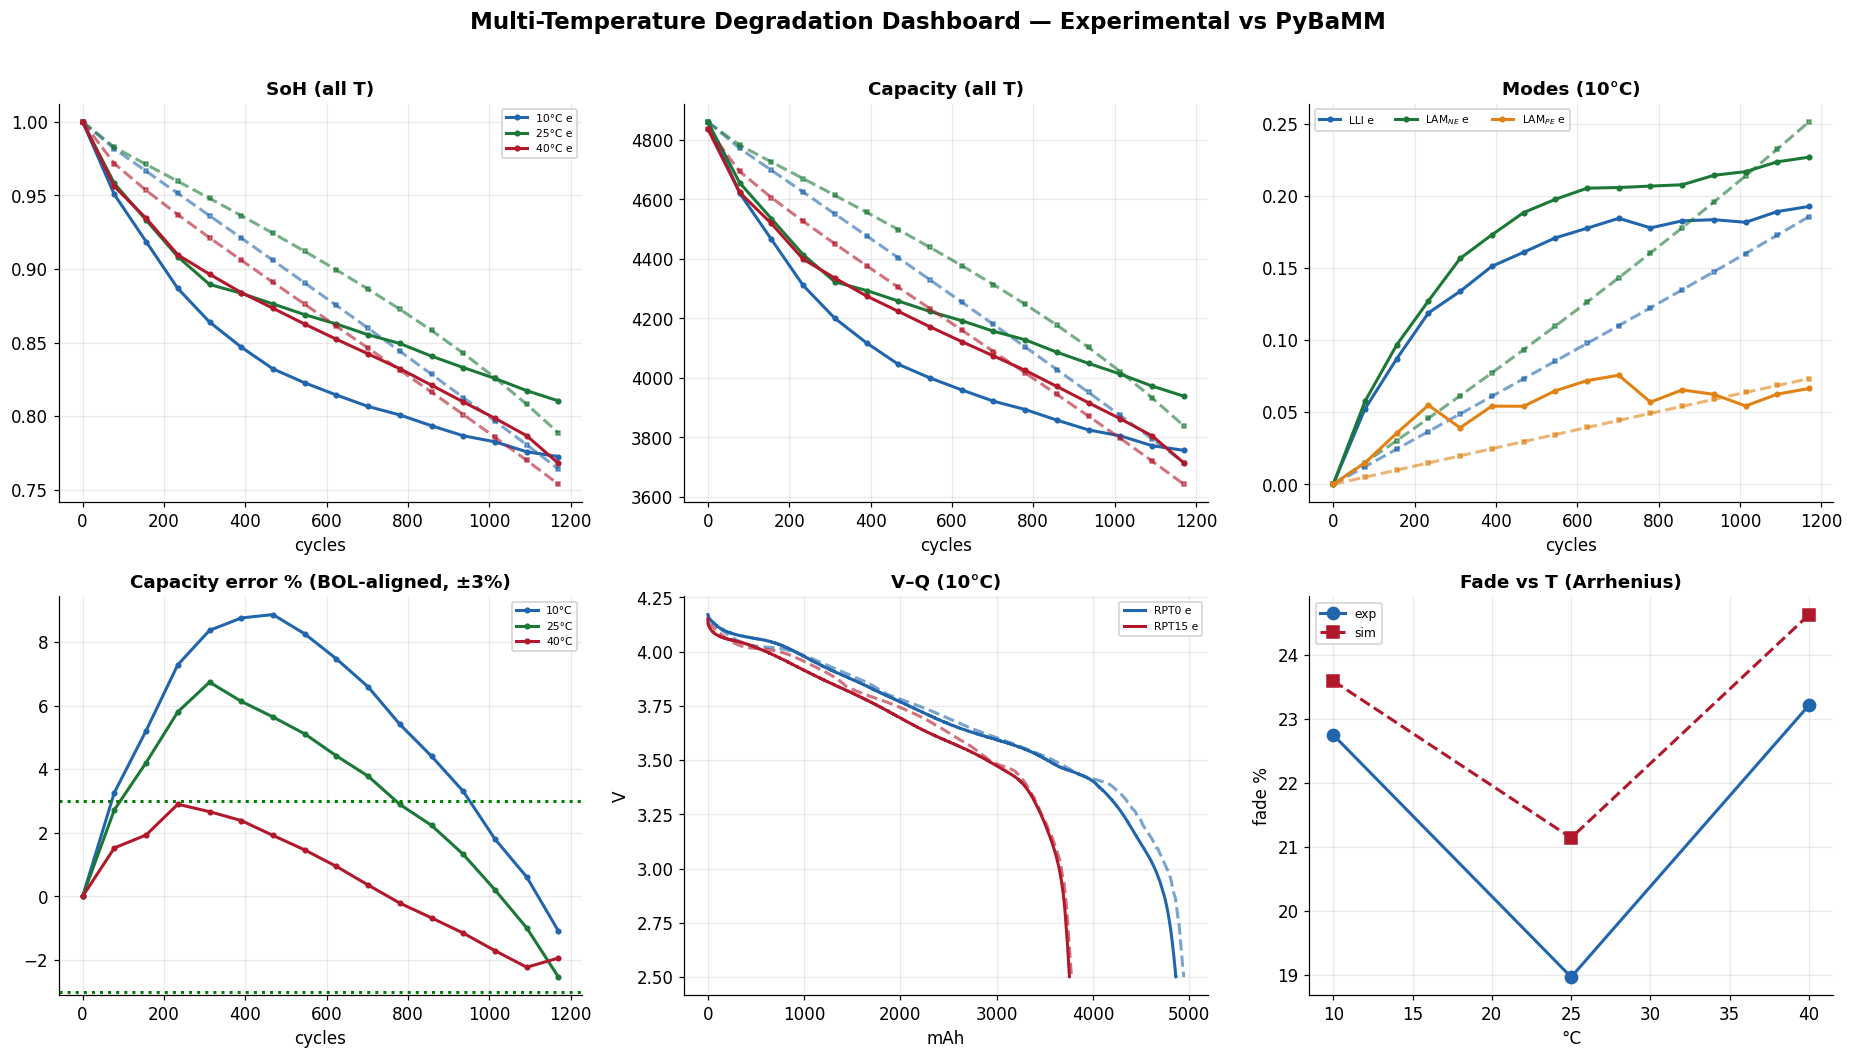

In [18]:
fig, ax = plt.subplots(2,3,figsize=(17,9.5))

for cell,(T,c) in CELLS.items():
    if cell not in DATA: continue
    d=DATA[cell]
    ax[0,0].plot(d["cyc"],col(d["exp"],"SoH"),"o-",c=c,ms=3,label=f"{T}°C e")
    ax[0,0].plot(d["cyc"],col(d["sim"],"SoH"),"s--",c=c,ms=3,alpha=0.6)
ax[0,0].set_title("SoH (all T)"); ax[0,0].set_xlabel("cycles"); ax[0,0].legend(fontsize=7)
# capacity all T
for cell,(T,c) in CELLS.items():
    if cell not in DATA: continue
    d=DATA[cell]
    exp_cap = col(d["exp"],"C/10 Capacity [mA h]")
    sim_cap = col(d["sim"],"C/10 Capacity [mA h]")


    sim_cap = sim_cap * (exp_cap[0] / sim_cap[0])

    ax[0,1].plot(d["cyc"], exp_cap, "o-",  c=c, ms=3)
    ax[0,1].plot(d["cyc"], sim_cap, "s--", c=c, ms=3, alpha=0.6)
ax[0,1].set_title("Capacity (all T)"); ax[0,1].set_xlabel("cycles")

d=DATA[ref]
for cn,lbl,cc in mode_cols:
    ax[0,2].plot(d["cyc"],col(d["exp"],cn),"o-",c=cc,ms=3,label=f"{lbl} e")
    ax[0,2].plot(d["cyc"],col(d["sim"],cn),"s--",c=cc,ms=3,alpha=0.6)
ax[0,2].set_title(f"Modes ({CELLS[ref][0]}°C)"); ax[0,2].set_xlabel("cycles"); ax[0,2].legend(fontsize=7,ncol=3)

for cell,(T,c) in CELLS.items():
    if cell not in DATA: continue
    d=DATA[cell]
    exp_cap = col(d["exp"],"C/10 Capacity [mA h]")
    sim_cap = col(d["sim"],"C/10 Capacity [mA h]")


    sim_cap = sim_cap * (exp_cap[0] / sim_cap[0])

    ce = (sim_cap - exp_cap) / exp_cap * 100
    ax[1,0].plot(d["cyc"], ce, "o-", c=c, ms=3, label=f"{T}°C")
ax[1,0].axhline(3,color="green",ls=":"); ax[1,0].axhline(-3,color="green",ls=":")
ax[1,0].set_title("Capacity error % (BOL-aligned, ±3%)"); ax[1,0].set_xlabel("cycles"); ax[1,0].legend(fontsize=7)

ecv=CURVES[ref]["exp"]; scv=CURVES[ref]["sim"]; cc2=sorted(set(ecv)&set(scv))
for r,c in [(cc2[0],"#2166AC"),(cc2[-1],"#B2182B")]:
    qe,ve=vq(ecv[r]); qs,vs=vq(scv[r])
    if qe is not None: ax[1,1].plot(qe,ve,"-",c=c,label=f"RPT{r} e")
    if qs is not None: ax[1,1].plot(qs,vs,"--",c=c,alpha=0.6)
ax[1,1].set_title(f"V–Q ({CELLS[ref][0]}°C)"); ax[1,1].set_xlabel("mAh"); ax[1,1].set_ylabel("V"); ax[1,1].legend(fontsize=7)

ax[1,2].plot(Ts,fade_e,"o-",c="#2166AC",ms=8,label="exp"); ax[1,2].plot(Ts,fade_s,"s--",c="#B2182B",ms=8,label="sim")
ax[1,2].set_title("Fade vs T (Arrhenius)"); ax[1,2].set_xlabel("°C"); ax[1,2].set_ylabel("fade %"); ax[1,2].legend(fontsize=8)
plt.suptitle("Multi-Temperature Degradation Dashboard — Experimental vs PyBaMM", fontweight="bold", y=1.01, fontsize=15)
plt.tight_layout(); plt.savefig(f"{FIGDIR}/fig15_dashboard.png"); plt.show()

## 12 · Feasibility Verdict

A quantitative, multi-temperature feasibility statement

In [19]:
import numpy as np
def error_report(exp, sim, cyc, bol_align=False):
    exp = np.asarray(exp, float); sim = np.asarray(sim, float)
    cyc = np.asarray(cyc, float)
    n = min(len(exp), len(sim), len(cyc))
    exp, sim, cyc = exp[:n], sim[:n], cyc[:n]

    if bol_align:
        if (cyc == 0).any():
            i0 = int(np.where(cyc == 0)[0][0])
        else:
            i0 = 0
        eb, sb = exp[i0], sim[i0]
        if np.isfinite(eb) and np.isfinite(sb) and sb != 0:
            sim = sim * (eb / sb)          # multiplicative -> preserves fade shape

    m = np.isfinite(exp) & np.isfinite(sim) & (exp != 0)
    if not m.any():
        return None
    e, s, c = exp[m], sim[m], cyc[m]
    pct      = (s - e) / e * 100.0          # signed % error per point
    abspct   = np.abs(pct)
    iworst   = int(np.argmax(abspct))
    bias     = float(np.mean(pct))          # +ve = sim over-predicts (under-fades)
    mape     = float(np.mean(abspct))
    rmse_abs = float(np.sqrt(np.mean((s - e) ** 2)))   # in the quantity's units
    r2       = float(1 - np.sum((s - e) ** 2) / np.sum((e - np.mean(e)) ** 2)) \
               if np.var(e) > 0 else np.nan
    eol_err  = float(pct[-1])               # signed error at last RPT
    return {
        "bias": bias, "mape": mape, "rmse_abs": rmse_abs, "r2": r2,
        "worst_pct": float(pct[iworst]), "worst_cyc": int(c[iworst]),
        "eol_pct": eol_err, "n": int(m.sum()),
    }

print("=" * 96)
print("  MULTI-TEMPERATURE FEASIBILITY SUMMARY  (BOL-aligned; +%=over-predict/under-fade)")
print("=" * 96)
hdr = (f"  {'cell':<6}{'T':>4}  {'horizon':<16}"
       f"{'Cap MAPE':>9}{'Cap RMSE':>11}{'Cap bias':>9}"
       f"{'worst (@cyc)':>16}{'EoL err':>9}{'SoH MAPE':>10}")
print(hdr)
print("-" * 96)
allcap = []
for cell in present:
    d = DATA[cell]; T = CELLS[cell][0]
    endcyc = int(d["cyc"][-1])
    tag = "full life" if endcyc >= 1100 else f"partial ({endcyc} cyc)"
    # capacity -> BOL-aligned so error reflects fade, not starting offset
    cap = error_report(col(d["exp"], "C/10 Capacity [mA h]"),
                       col(d["sim"], "C/10 Capacity [mA h]"),
                       d["cyc"], bol_align=True)
    # SoH -> no alignment needed (already normalised, BOL=1)
    soh = error_report(col(d["exp"], "SoH"),
                       col(d["sim"], "SoH"),
                       d["cyc"], bol_align=False)
    if cap is None:
        print(f"  {cell:<6}{T:>3}°  {tag:<16}  (no overlapping finite data)")
        continue
    allcap.append(cap["mape"])
    print(f"  {cell:<6}{T:>3}°  {tag:<16}"
          f"{cap['mape']:>8.2f}%{cap['rmse_abs']:>9.0f}mAh{cap['bias']:>+8.2f}%"
          f"{cap['worst_pct']:>+9.1f}% @{cap['worst_cyc']:<5d}"
          f"{cap['eol_pct']:>+8.2f}%{soh['mape']:>9.2f}%")
print("-" * 96)
overall = float(np.mean(allcap)) if allcap else np.nan
worst_cell_mape = float(np.max(allcap)) if allcap else np.nan
verdict = ("PASS — multi-T calibration validated." if overall < 4 else
           "MARGINAL — usable as prior; refine hottest cell"        if overall < 8 else
           "NEEDS WORK")
print(f"  Mean capacity MAPE across temperatures : {overall:.2f}%")
print(f"  Worst single-cell MAPE                 : {worst_cell_mape:.2f}%")
print(f"  VERDICT: {verdict}")


  MULTI-TEMPERATURE FEASIBILITY SUMMARY  (BOL-aligned; +%=over-predict/under-fade)
  cell     T  horizon          Cap MAPE   Cap RMSE Cap bias    worst (@cyc)  EoL err  SoH MAPE
------------------------------------------------------------------------------------------------
  A      10°  full life           5.04%      239mAh   +4.91%     +8.9% @468     -1.09%     5.04%
  D      25°  full life           3.42%      172mAh   +2.98%     +6.7% @312     -2.54%     3.31%
  F      40°  full life           1.50%       73mAh   +0.51%     +2.9% @234     -1.94%     1.52%
------------------------------------------------------------------------------------------------
  Mean capacity MAPE across temperatures : 3.32%
  Worst single-cell MAPE                 : 5.04%
  VERDICT: PASS — multi-T calibration validated.


## 13 · Chapter 8 (Results) — separate figures, one per slot

The cells below are **only for the thesis Results chapter**. They reuse the data
already loaded above (`DATA`, `CURVES`, `col`, `err_stats`, `vq`, `compute_ica`,
`compute_dva`) and save each figure **separately** into a `results/` folder, with
the exact filenames the Chapter 8 LaTeX expects:

| File | What it is | Chapter 8 figure |
|------|-----------|------------------|
| `fit_cellD.png` | 4-panel sim-vs-exp (calibration) | 8.1 |
| `fit_cellF.png` | 4-panel sim-vs-exp (calibration) | 8.2 |
| `arrhenius_fit.png` | ln(beta) vs 1/T per knob | 8.3 |
| `ica_dva_sim_vs_exp.png` | sim ICA/DVA over exp | 8.4 |
| `fit_cellA.png` | 4-panel sim-vs-exp (validation) | 8.5 |
| `cellA_residual.png` | unexplained fade = plating | 8.6 |
| `table_rmse.csv`, `table_mape.csv` | error tables | tables |

Run everything above first, then run these. Copy the `results/` folder next to
your `.tex` file (or set `\graphicspath{{results/}}`).

In [20]:
import os
CH8DIR = "results"
os.makedirs(CH8DIR, exist_ok=True)

# measured mean cell temperatures (NOT the 10/25/40 chamber setpoints)
TMEAS_C = {"A": 10, "D": 25, "F": 40}
TMEAS_K = {k: v + 273.15 for k, v in TMEAS_C.items()}
print("Chapter 8 figures ->", os.path.abspath(CH8DIR))
print("measured temps:", TMEAS_C)

Chapter 8 figures -> C:\Users\yashb\ML\results
measured temps: {'A': 10, 'D': 25, 'F': 40}


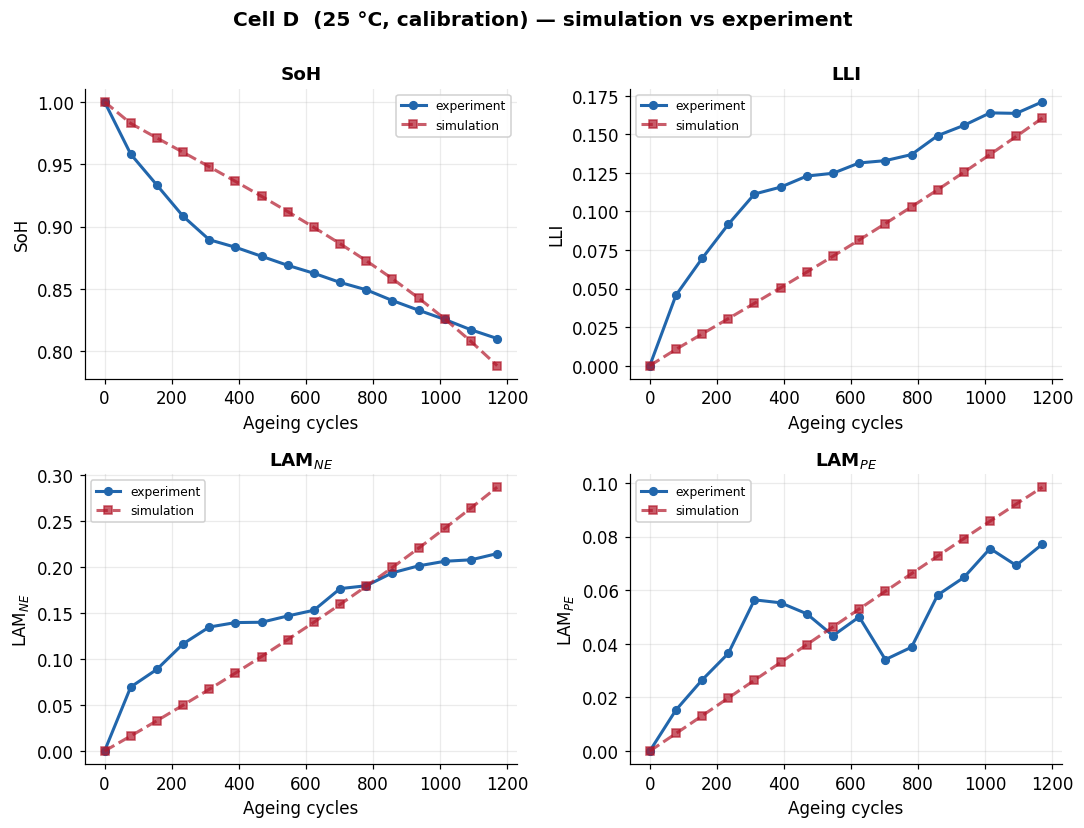

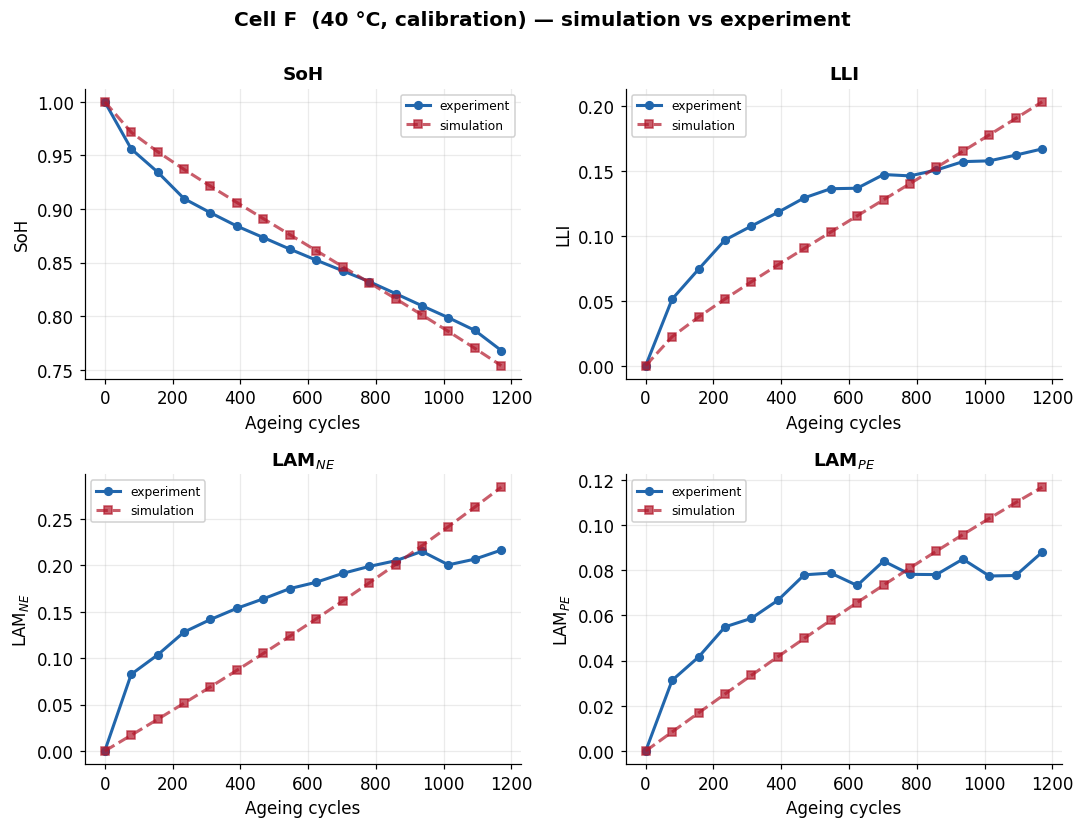

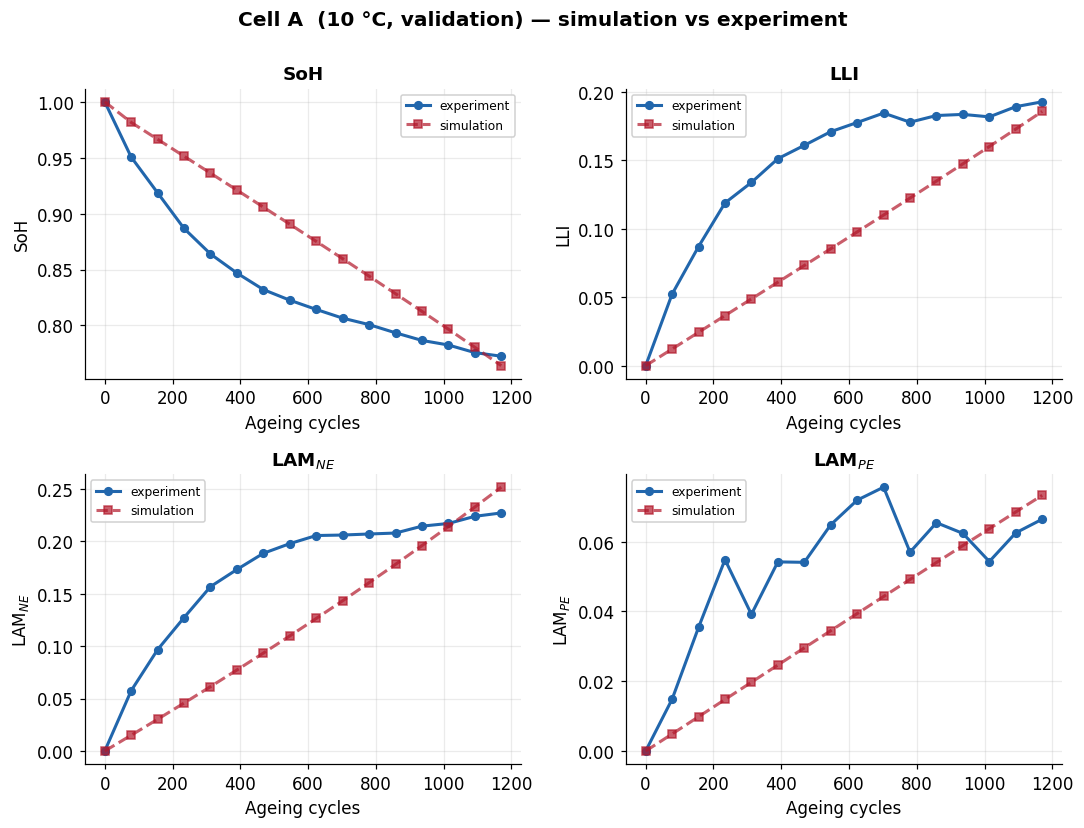

In [21]:
# --- Figures 8.1 / 8.2 / 8.5: four-panel sim-vs-exp, one file per cell ---
def four_panel(cell, fname):
    if cell not in DATA:
        print("skip", cell, "- not in DATA"); return
    d = DATA[cell]; cyc = d["cyc"]
    panels = [("SoH", "SoH"), ("LLI", "LLI"),
              ("LAM NE_tot", "LAM$_{NE}$"), ("LAM PE", "LAM$_{PE}$")]
    fig, ax = plt.subplots(2, 2, figsize=(10, 7.5))
    for axi, (cn, lbl) in zip(ax.ravel(), panels):
        e = col(d["exp"], cn); s = col(d["sim"], cn)
        axi.plot(cyc, e, "o-",  c="#2166AC", label="experiment")
        axi.plot(cyc, s, "s--", c="#B2182B", alpha=0.7, label="simulation")
        axi.set_xlabel("Ageing cycles"); axi.set_ylabel(lbl); axi.set_title(lbl)
        axi.legend(fontsize=8)
    role = "validation" if cell == "A" else "calibration"
    fig.suptitle(f"Cell {cell}  ({TMEAS_C.get(cell,'?')} \u00b0C, {role}) \u2014 simulation vs experiment",
                 fontweight="bold", y=1.0)
    plt.tight_layout(); plt.savefig(f"{CH8DIR}/{fname}"); plt.show()

four_panel("D", "fit_cellD.png")   # 8.2 calibration
four_panel("F", "fit_cellF.png")   # 8.3 calibration
four_panel("A", "fit_cellA.png")   # 8.5 validation

In [22]:
# --- Error tables: per-signal RMSE (D, F, A) and overall MAPE per cell ---
sig = [("SoH", "SoH"), ("LLI", "LLI"), ("LAM NE_tot", "LAM_NE"), ("LAM PE", "LAM_PE")]

# per-signal RMSE
rows = []
for cell in ["D", "F", "A"]:
    if cell not in DATA: continue
    d = DATA[cell]; row = {"Cell": f"{cell} ({TMEAS_C[cell]} C)"}
    for cn, lbl in sig:
        st = err_stats(col(d["exp"], cn), col(d["sim"], cn))
        row[f"RMSE {lbl}"] = round(st["rmse"], 4) if st else None
    rows.append(row)
rmse_tab = pd.DataFrame(rows)
print("Per-signal RMSE:"); print(rmse_tab.to_string(index=False))
rmse_tab.to_csv(f"{CH8DIR}/table_rmse.csv", index=False)

# overall MAPE per cell (mean of the four signals)
rows = []
for cell in ["D", "F", "A"]:
    if cell not in DATA: continue
    d = DATA[cell]; mapes = []
    for cn, _ in sig:
        st = err_stats(col(d["exp"], cn), col(d["sim"], cn))
        if st: mapes.append(st["mape"])
    rows.append({"Cell": f"{cell} ({TMEAS_C[cell]} C)",
                 "role": "calibration" if cell in ("D", "F") else "validation",
                 "MAPE %": round(float(np.nanmean(mapes)), 2)})
mape_tab = pd.DataFrame(rows)
print("\nMAPE per cell:"); print(mape_tab.to_string(index=False))
mape_tab.to_csv(f"{CH8DIR}/table_mape.csv", index=False)

Per-signal RMSE:
    Cell  RMSE SoH  RMSE LLI  RMSE LAM_NE  RMSE LAM_PE
D (25 C)    0.0343    0.0447       0.0438       0.0176
F (40 C)    0.0154    0.0294       0.0519       0.0215
A (10 C)    0.0492    0.0623       0.0623       0.0217

MAPE per cell:
    Cell        role  MAPE %
D (25 C) calibration    3.31
F (40 C) calibration    1.52
A (10 C)  validation    5.04


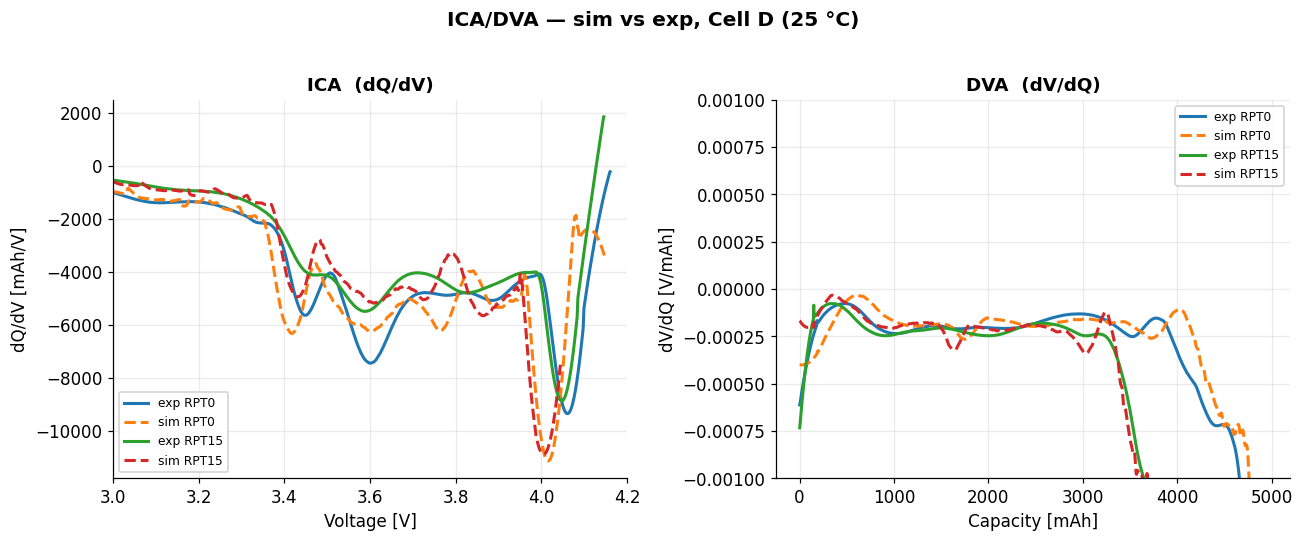

In [23]:
# --- Figure 8.4: simulated ICA/DVA overlaid on experimental, one cell ---
def ica_dva_overlay(cell, fname):
    if cell not in CURVES:
        print("skip", cell, "- no curves"); return
    ec = CURVES[cell]["exp"]; sc = CURVES[cell]["sim"]
    common = sorted(set(ec) & set(sc))
    if not common:
        print("no overlapping curves for", cell); return
    rpts = [common[0], common[-1]] if len(common) > 1 else [common[0]]
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
    for r in rpts:
        qe, ve = vq(ec[r]); qs, vs = vq(sc[r])
        vge, ie = compute_ica(qe, ve); vgs, isi = compute_ica(qs, vs)
        if vge is not None: ax[0].plot(vge, ie,  "-",  label=f"exp RPT{r}")
        if vgs is not None: ax[0].plot(vgs, isi, "--", label=f"sim RPT{r}")
        qge, de = compute_dva(qe, ve); qgs, ds = compute_dva(qs, vs)
        if qge is not None: ax[1].plot(qge, de, "-",  label=f"exp RPT{r}")
        if qgs is not None: ax[1].plot(qgs, ds, "--", label=f"sim RPT{r}")
    ax[0].set_xlim(3.0, 4.2); ax[0].set_xlabel("Voltage [V]"); ax[0].set_ylabel("dQ/dV [mAh/V]")
    ax[0].set_title("ICA  (dQ/dV)"); ax[0].legend(fontsize=8)
    ax[1].set_ylim(-1e-3, 1e-3); ax[1].set_xlabel("Capacity [mAh]"); ax[1].set_ylabel("dV/dQ [V/mAh]")
    ax[1].set_title("DVA  (dV/dQ)"); ax[1].legend(fontsize=8)
    fig.suptitle(f"ICA/DVA \u2014 sim vs exp, Cell {cell} ({TMEAS_C.get(cell,'?')} \u00b0C)",
                 fontweight="bold", y=1.02)
    plt.tight_layout(); plt.savefig(f"{CH8DIR}/{fname}"); plt.show()

ica_dva_overlay("D", "ica_dva_sim_vs_exp.png")   # use a calibration cell

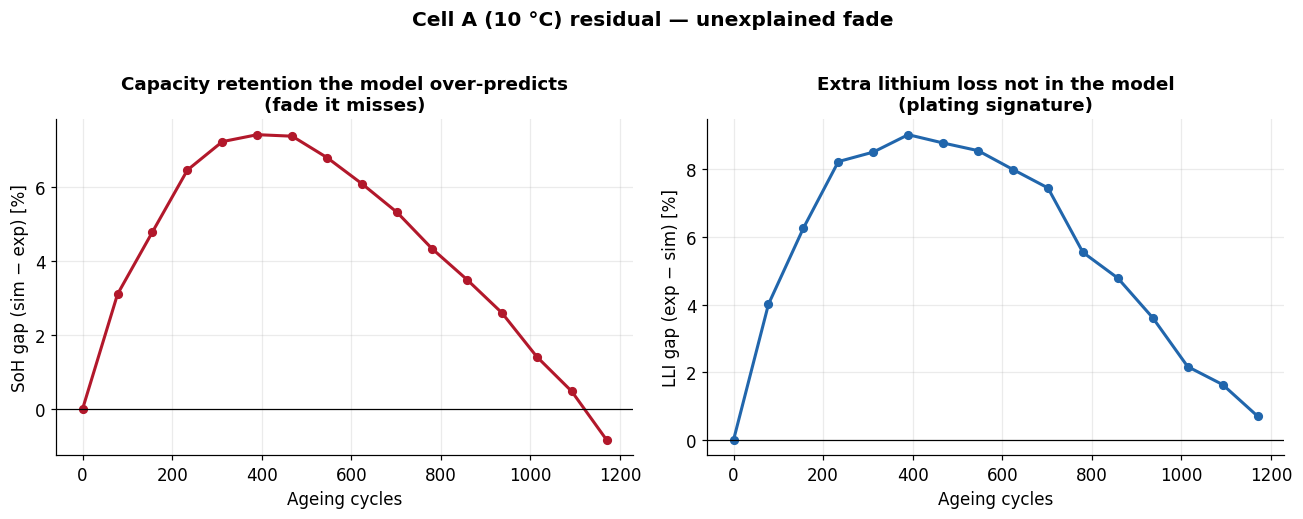

In [24]:
# --- Figure 8.6: Cell A residual = the fade the model cannot explain (plating) ---
def cellA_residual(cell="A", fname="cellA_residual.png"):
    if cell not in DATA:
        print("skip", cell, "- not in DATA"); return
    d = DATA[cell]; cyc = d["cyc"]
    soh_e = col(d["exp"], "SoH"); soh_s = col(d["sim"], "SoH")
    lli_e = col(d["exp"], "LLI"); lli_s = col(d["sim"], "LLI")
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
    ax[0].plot(cyc, (soh_s - soh_e) * 100, "o-", c="#B2182B")
    ax[0].axhline(0, color="k", lw=0.8)
    ax[0].set_xlabel("Ageing cycles"); ax[0].set_ylabel("SoH gap (sim \u2212 exp) [%]")
    ax[0].set_title("Capacity retention the model over-predicts\n(fade it misses)")
    ax[1].plot(cyc, (lli_e - lli_s) * 100, "o-", c="#2166AC")
    ax[1].axhline(0, color="k", lw=0.8)
    ax[1].set_xlabel("Ageing cycles"); ax[1].set_ylabel("LLI gap (exp \u2212 sim) [%]")
    ax[1].set_title("Extra lithium loss not in the model\n(plating signature)")
    fig.suptitle(f"Cell {cell} ({TMEAS_C.get(cell,'?')} \u00b0C) residual \u2014 unexplained fade",
                 fontweight="bold", y=1.02)
    plt.tight_layout(); plt.savefig(f"{CH8DIR}/{fname}"); plt.show()

cellA_residual()

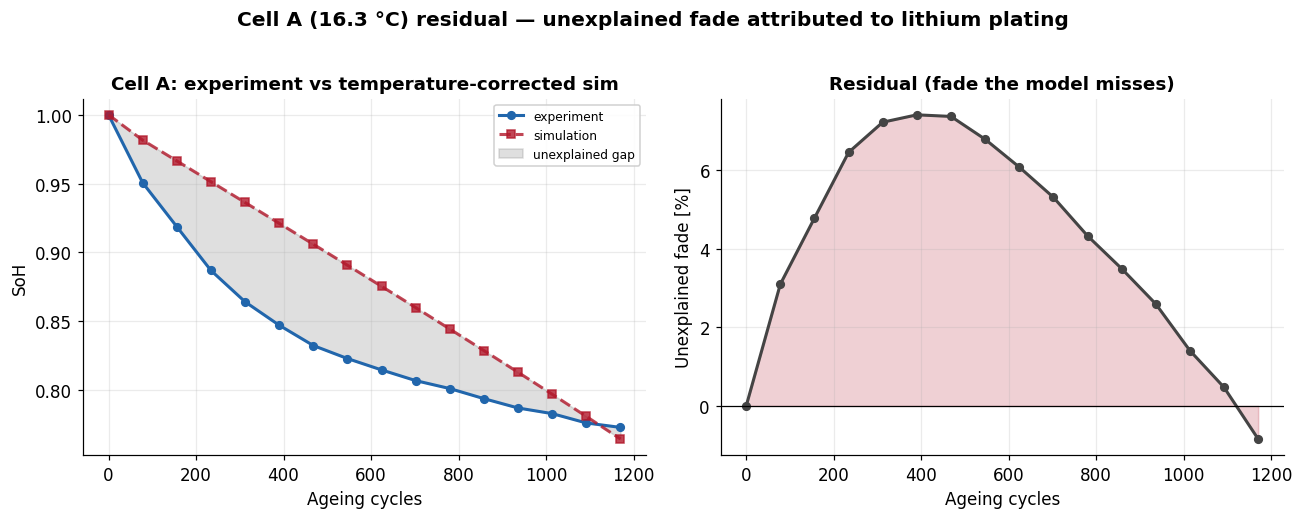

max unexplained fade : 7.42 %
end-of-life residual : -0.84 %


In [27]:
import os
CH8DIR = "results"; os.makedirs(CH8DIR, exist_ok=True)
TMEAS_C = {"A": 16.3}

cell = "A"
if cell not in DATA:
    print("Cell A not in DATA - run the loading cells first.")
else:
    d   = DATA[cell]
    cyc = d["cyc"]
    soh_e = col(d["exp"], "SoH")
    soh_s = col(d["sim"], "SoH")

    residual_pct = (soh_s - soh_e) * 100.0

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))

    # (a) SoH curves with the gap shaded
    ax[0].plot(cyc, soh_e, "o-",  c="#2166AC", label="experiment")
    ax[0].plot(cyc, soh_s, "s--", c="#B2182B", alpha=0.8, label="simulation")
    ax[0].fill_between(cyc, soh_e, soh_s, color="grey", alpha=0.25,
                       label="unexplained gap")
    ax[0].set_xlabel("Ageing cycles"); ax[0].set_ylabel("SoH")
    ax[0].set_title("Cell A: experiment vs temperature-corrected sim")
    ax[0].legend(fontsize=8)

    # (b) the residual itself
    ax[1].plot(cyc, residual_pct, "o-", c="#444444")
    ax[1].fill_between(cyc, 0, residual_pct, color="#B2182B", alpha=0.20)
    ax[1].axhline(0, color="k", lw=0.8)
    ax[1].set_xlabel("Ageing cycles")
    ax[1].set_ylabel("Unexplained fade [%]")
    ax[1].set_title("Residual (fade the model misses)")

    fig.suptitle(f"Cell A ({TMEAS_C['A']} \u00b0C) residual "
                 f"\u2014 unexplained fade attributed to lithium plating",
                 fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(f"{CH8DIR}/cellA_residual.png")
    plt.show()

   
    print(f"max unexplained fade : {np.nanmax(residual_pct):.2f} %")
    print(f"end-of-life residual : {residual_pct[np.isfinite(residual_pct)][-1]:.2f} %")

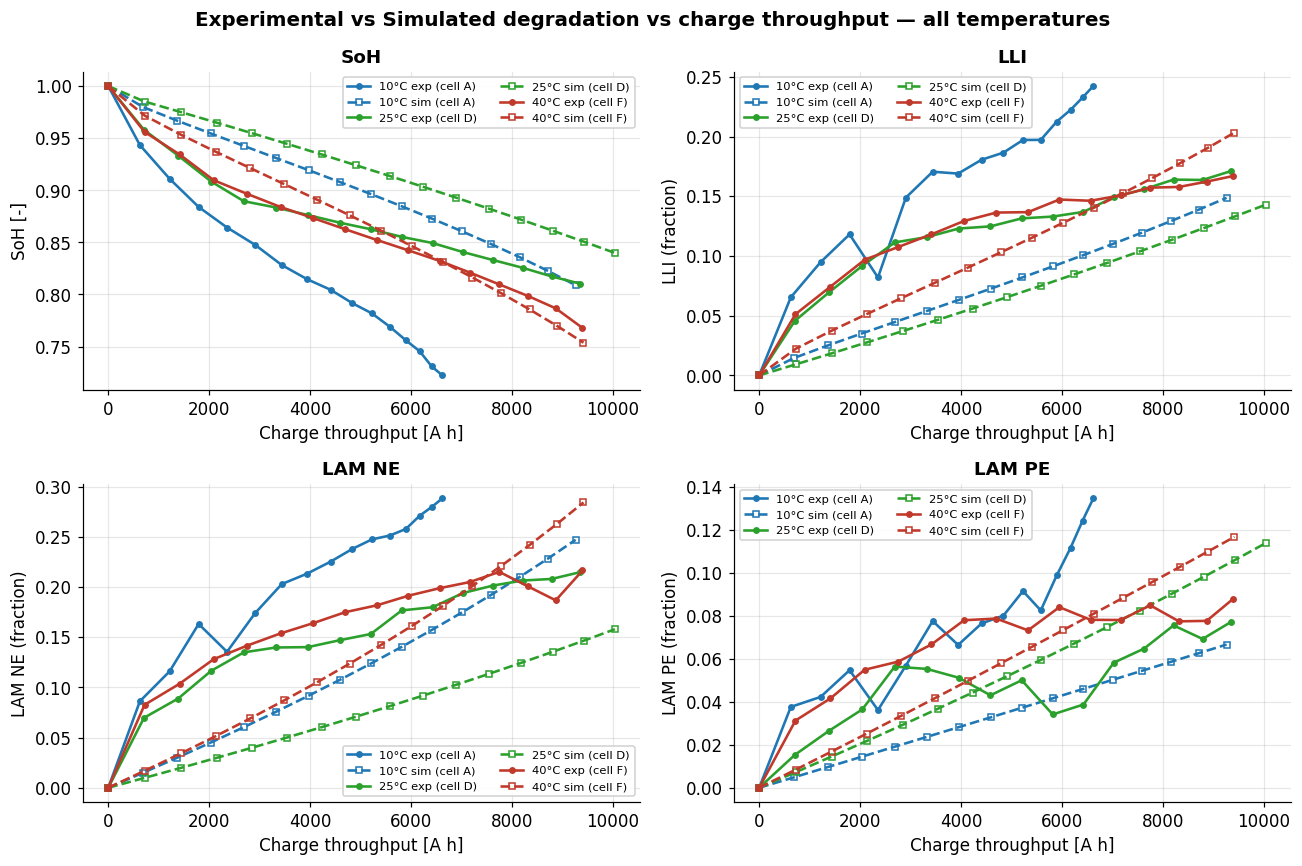

In [29]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXP_DIR = r"D:\Mtech\Battery (MTP)\Stage 2\Data\IMP_1\Expt 5 - Standard Cycle Aging (Control)\exp_output"  
SIM_DIR = r"D:\Mtech\Battery (MTP)\Stage 2\Output Exp Data\kirkaldy pybamm\sim_output_6\Summary Data\Performance Summary"


CELLS_BY_TEMP = {10: ["A"], 25: ["D"], 40: ["F"]}
TEMP_COLOR    = {10: "#1f77b4", 25: "#2ca02c", 40: "#c0392b"}


METRICS = {
    "SoH":    ["SoH", "SOH"],
    "LLI":    ["LLI"],
    "LAM NE": ["LAM NE_tot", "LAM NE", "LAM_NE_tot", "LAM_NE"],
    "LAM PE": ["LAM PE", "LAM_PE"],
}
X_CANDS = ["Charge Throughput [A h]", "Charge Throughput [A.h]",
           "Charge Throughput [Ah]", "Charge throughput [A.h]"]

# ─── helpers ─────────────────────────────────────────────────────────────────
def _find(directory, cell_id):
    for pat in (f"*cell {cell_id} *Processed*.csv", f"*cell {cell_id}*Processed*.csv",
                f"*cell_{cell_id}*Processed*.csv", f"*{cell_id}*Processed*.csv"):
        hits = glob.glob(os.path.join(directory, "**", pat), recursive=True)
        if hits:
            return sorted(hits)[0]
    return None

def _col(df, cands):
    low = {c.lower(): c for c in df.columns}
    for c in cands:
        if c in df.columns:       return c
        if c.lower() in low:      return low[c.lower()]
    return None

def _norm(series, is_soh):
    """Put everything on the same scale: SoH as a fraction (~0.7-1.0),
    LLI/LAM as a fraction (0-1). If the file stored percentages, rescale."""
    s = pd.to_numeric(series, errors="coerce")
    med = np.nanmedian(s.values)
    if is_soh:
        return s / 100 if med > 1.5 else s          # 95 -> 0.95
    return s / 100 if med > 1.0 else s              # 18 -> 0.18

def _load(directory, cell_id):
    f = _find(directory, cell_id)
    if f is None:
        print(f"  ⚠ no processed CSV for cell {cell_id} in {directory}")
        return None
    df = pd.read_csv(f)
    xc = _col(df, X_CANDS)
    if xc is None:
        print(f"  ⚠ no charge-throughput column in {os.path.basename(f)}")
        return None
    out = {"x": pd.to_numeric(df[xc], errors="coerce")}
    for m, cands in METRICS.items():
        c = _col(df, cands)
        out[m] = _norm(df[c], is_soh=(m == "SoH")) if c else None
    return out

# ─── plot: 2x2 grid, exp solid + filled marker, sim dashed + open marker ─────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
names = list(METRICS.keys())

for T, cells in CELLS_BY_TEMP.items():
    color = TEMP_COLOR.get(T, "k")
    for cell in cells:
        exp = _load(EXP_DIR, cell)
        sim = _load(SIM_DIR, cell)
        for ax, m in zip(axes, names):
            if exp and exp[m] is not None:
                ax.plot(exp["x"], exp[m], "-o", color=color, ms=3.5, lw=1.7,
                        label=f"{T}°C exp (cell {cell})")
            if sim and sim[m] is not None:
                ax.plot(sim["x"], sim[m], "--s", color=color, ms=3.5, lw=1.7,
                        mfc="none", label=f"{T}°C sim (cell {cell})")

for ax, m in zip(axes, names):
    ax.set_title(m, fontweight="bold")
    ax.set_xlabel("Charge throughput [A h]")
    ax.set_ylabel(m + (" [-]" if m == "SoH" else " (fraction)"))
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7.5, ncol=2)

fig.suptitle("Experimental vs Simulated degradation vs charge throughput — all temperatures",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()